<a href="https://colab.research.google.com/github/Fiarma/Data-Science-Projects/blob/fiarma/Agricultural_Product_Distribution_Forecasting_Predicting_Demand_to_Optimize_Harvest_Schedules.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Import packages

In [ ]:
# Importation des bibliothèques nécessaires

# Bibliothèque pour la manipulation de données
import pandas as pd

# Bibliothèque pour les opérations mathématiques et les manipulations de tableaux
import numpy as np

# Bibliothèque pour la visualisation de données
import matplotlib.pyplot as plt

# Bibliothèque pour la visualisation de données statistiques
import seaborn as sns

# Bibliothèque pour les fonctions statistiques
from scipy import stats

# Bibliothèque pour les tests de stationnarité des séries temporelles
from statsmodels.tsa.stattools import adfuller

# Bibliothèque pour le modèle ARIMA (AutoRegressive Integrated Moving Average)
from statsmodels.tsa.arima_model import ARIMA

# Bibliothèque pour tracer les fonctions d'autocorrélation (ACF) et d'autocorrélation partielle (PACF)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Bibliothèque Prophet pour la prévision des séries temporelles
from prophet import Prophet

# Bibliothèque pour le modèle RandomForestRegressor (régression par forêts aléatoires)
from sklearn.ensemble import RandomForestRegressor

# Bibliothèque pour diviser les données en ensembles d'entraînement et de test
from sklearn.model_selection import train_test_split

# Bibliothèque pour les métriques d'évaluation des modèles
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

# Suppression des avertissements pour une sortie plus propre
import warnings
warnings.filterwarnings('ignore')


##Data Collection

In [ ]:
!pip install gdown
import gdown

In [ ]:
#https://drive.google.com/file/d/1EvvM4hkW35s1jN888WotGNHdfYiZTawj/view?usp=sharing

file_id = '1EvvM4hkW35s1jN888WotGNHdfYiZTawj'

output_file = 'Dataset.csv'

gdown.download(id = file_id, output=output_file, quiet=False)

df = pd.read_csv(output_file)

Downloading...
From: https://drive.google.com/uc?id=1EvvM4hkW35s1jN888WotGNHdfYiZTawj
To: /content/Dataset.csv
100%|██████████| 4.22M/4.22M [00:00<00:00, 23.2MB/s]


##Data Exploration and Understanding

In [ ]:
df.head()

,Date,Product,Quantity_Sold,Revenue,Temperature_Celsius,Rainfall_mm,Location,Transportation_Cost,Labor_Cost,Customer,Quality_Score,Inventory_Level
0,2015-01-01,Strawberries,690.0,70.298339,9.680289,0.077279,Field C,20,13.771809,Customer B,0.769340,3608.0
1,2015-01-01,Apples,354.0,599.863944,9.680289,0.077279,Field A,50,9.702670,Customer C,0.861953,3982.0
2,2015-01-01,Tomatoes,275.0,199.249505,9.680289,0.077279,Field C,20,22.356498,Customer C,0.861953,3708.0
3,2015-01-01,Apples,1079.0,1136.111770,9.680289,0.077279,Field A,50,15.691418,Customer A,0.876056,3455.0
4,2015-01-01,Strawberries,1008.0,111.653303,9.680289,0.077279,Field B,30,17.473353,Customer B,0.769340,1504.0


##Getting a descriptive static  of the numerical columns  of the dataset

In [ ]:
df.describe()

,Quantity_Sold,Revenue,Temperature_Celsius,Rainfall_mm,Transportation_Cost,Labor_Cost,Quality_Score,Inventory_Level
count,28382.000000,28388.000000,28377.000000,28377.000000,28388.000000,28388.000000,28388.000000,28382.000000
mean,609.197097,405.584444,20.024600,7.393332,33.465901,17.573430,0.835909,2617.164012
std,316.521726,485.206130,8.701719,4.316396,12.466448,7.232465,0.047362,1189.840946
min,41.000000,3.546003,5.011709,0.003963,20.000000,5.000083,0.769340,66.000000
25%,334.000000,94.572138,12.435564,3.621238,20.000000,11.289710,0.769340,1621.000000
50%,607.500000,256.513966,20.124216,7.358936,30.000000,17.586134,0.861953,2630.000000
75%,884.000000,513.624224,27.544882,11.062843,50.000000,23.869033,0.876056,3597.000000
max,1195.000000,3382.034941,34.985404,14.997572,50.000000,29.998989,0.876056,5172.000000


Check for missing values

In [ ]:
missing_values =  df.isnull().sum()

missing_values

Date                    0
Product                 0
Quantity_Sold           6
Revenue                 0
Temperature_Celsius    11
Rainfall_mm            11
Location                0
Transportation_Cost     0
Labor_Cost              0
Customer                0
Quality_Score           0
Inventory_Level         6
dtype: int64

Check for outlier

In [ ]:
# Définir les colonnes pour lesquelles on veut détecter les outliers
cols = ['Quantity_Sold', 'Temperature_Celsius', 'Rainfall_mm', 'Inventory_Level']

# Boucle à travers chaque colonne dans la liste des colonnes
for col in cols:
    # Calculer le Z-score pour chaque valeur dans la colonne, en omettant les valeurs NaN
    # le Z-score correpond en statistique a la loi normale :
    z = np.abs(stats.zscore(df[col], nan_policy='omit'))

    # Sélectionner les valeurs dont le Z-score est supérieur à 3 (outliers)
    outliers = df[col][z > 3]

    # Imprimer le nombre d'outliers trouvés pour chaque colonne
    print(f"{col} has {len(outliers)} outliers")


Quantity_Sold has 0 outliers
Temperature_Celsius has 0 outliers
Rainfall_mm has 0 outliers
Inventory_Level has 0 outliers


check for skewness ===> vérifier l’asymétrie

In [ ]:
# Définir les colonnes pour lesquelles on veut mesurer la skewness (asymétrie)
cols = ['Quantity_Sold', 'Temperature_Celsius', 'Rainfall_mm', 'Inventory_Level']

# Boucle à travers chaque colonne dans la liste des colonnes
for col in cols:
    # Calculer la skewness (asymétrie) pour chaque colonne
    skew = df[col].skew()

    # Imprimer la skewness trouvée pour chaque colonne
    print(f"{col} has a skewness of {skew}")


Quantity_Sold has a skewness of 0.007049968334628765
Temperature_Celsius has a skewness of -0.005244633606917498
Rainfall_mm has a skewness of 0.017580193058957767
Inventory_Level has a skewness of -0.006928239182168006


Fill  in the missing values  with  the mean ===> Remplissez les valeurs manquantes avec la moyenne

In [ ]:
# Boucle à travers chaque colonne pour remplir les valeurs manquantes
for col in cols:
    # Remplacer les valeurs manquantes par la moyenne de la colonne
    df[col].fillna(df[col].mean(), inplace=True)

In [ ]:

## Confirm that there is no missing values

In [ ]:
missing_values = df.isnull().sum()

missing_values

Date                   0
Product                0
Quantity_Sold          0
Revenue                0
Temperature_Celsius    0
Rainfall_mm            0
Location               0
Transportation_Cost    0
Labor_Cost             0
Customer               0
Quality_Score          0
Inventory_Level        0
dtype: int64

## Univariate  Analysis

Here,  we will  analyse the distribution of  variables individually for :

    - Categorical variables,
    
    - Numerical variables

## Univariate Analysis :  Numerical Variables

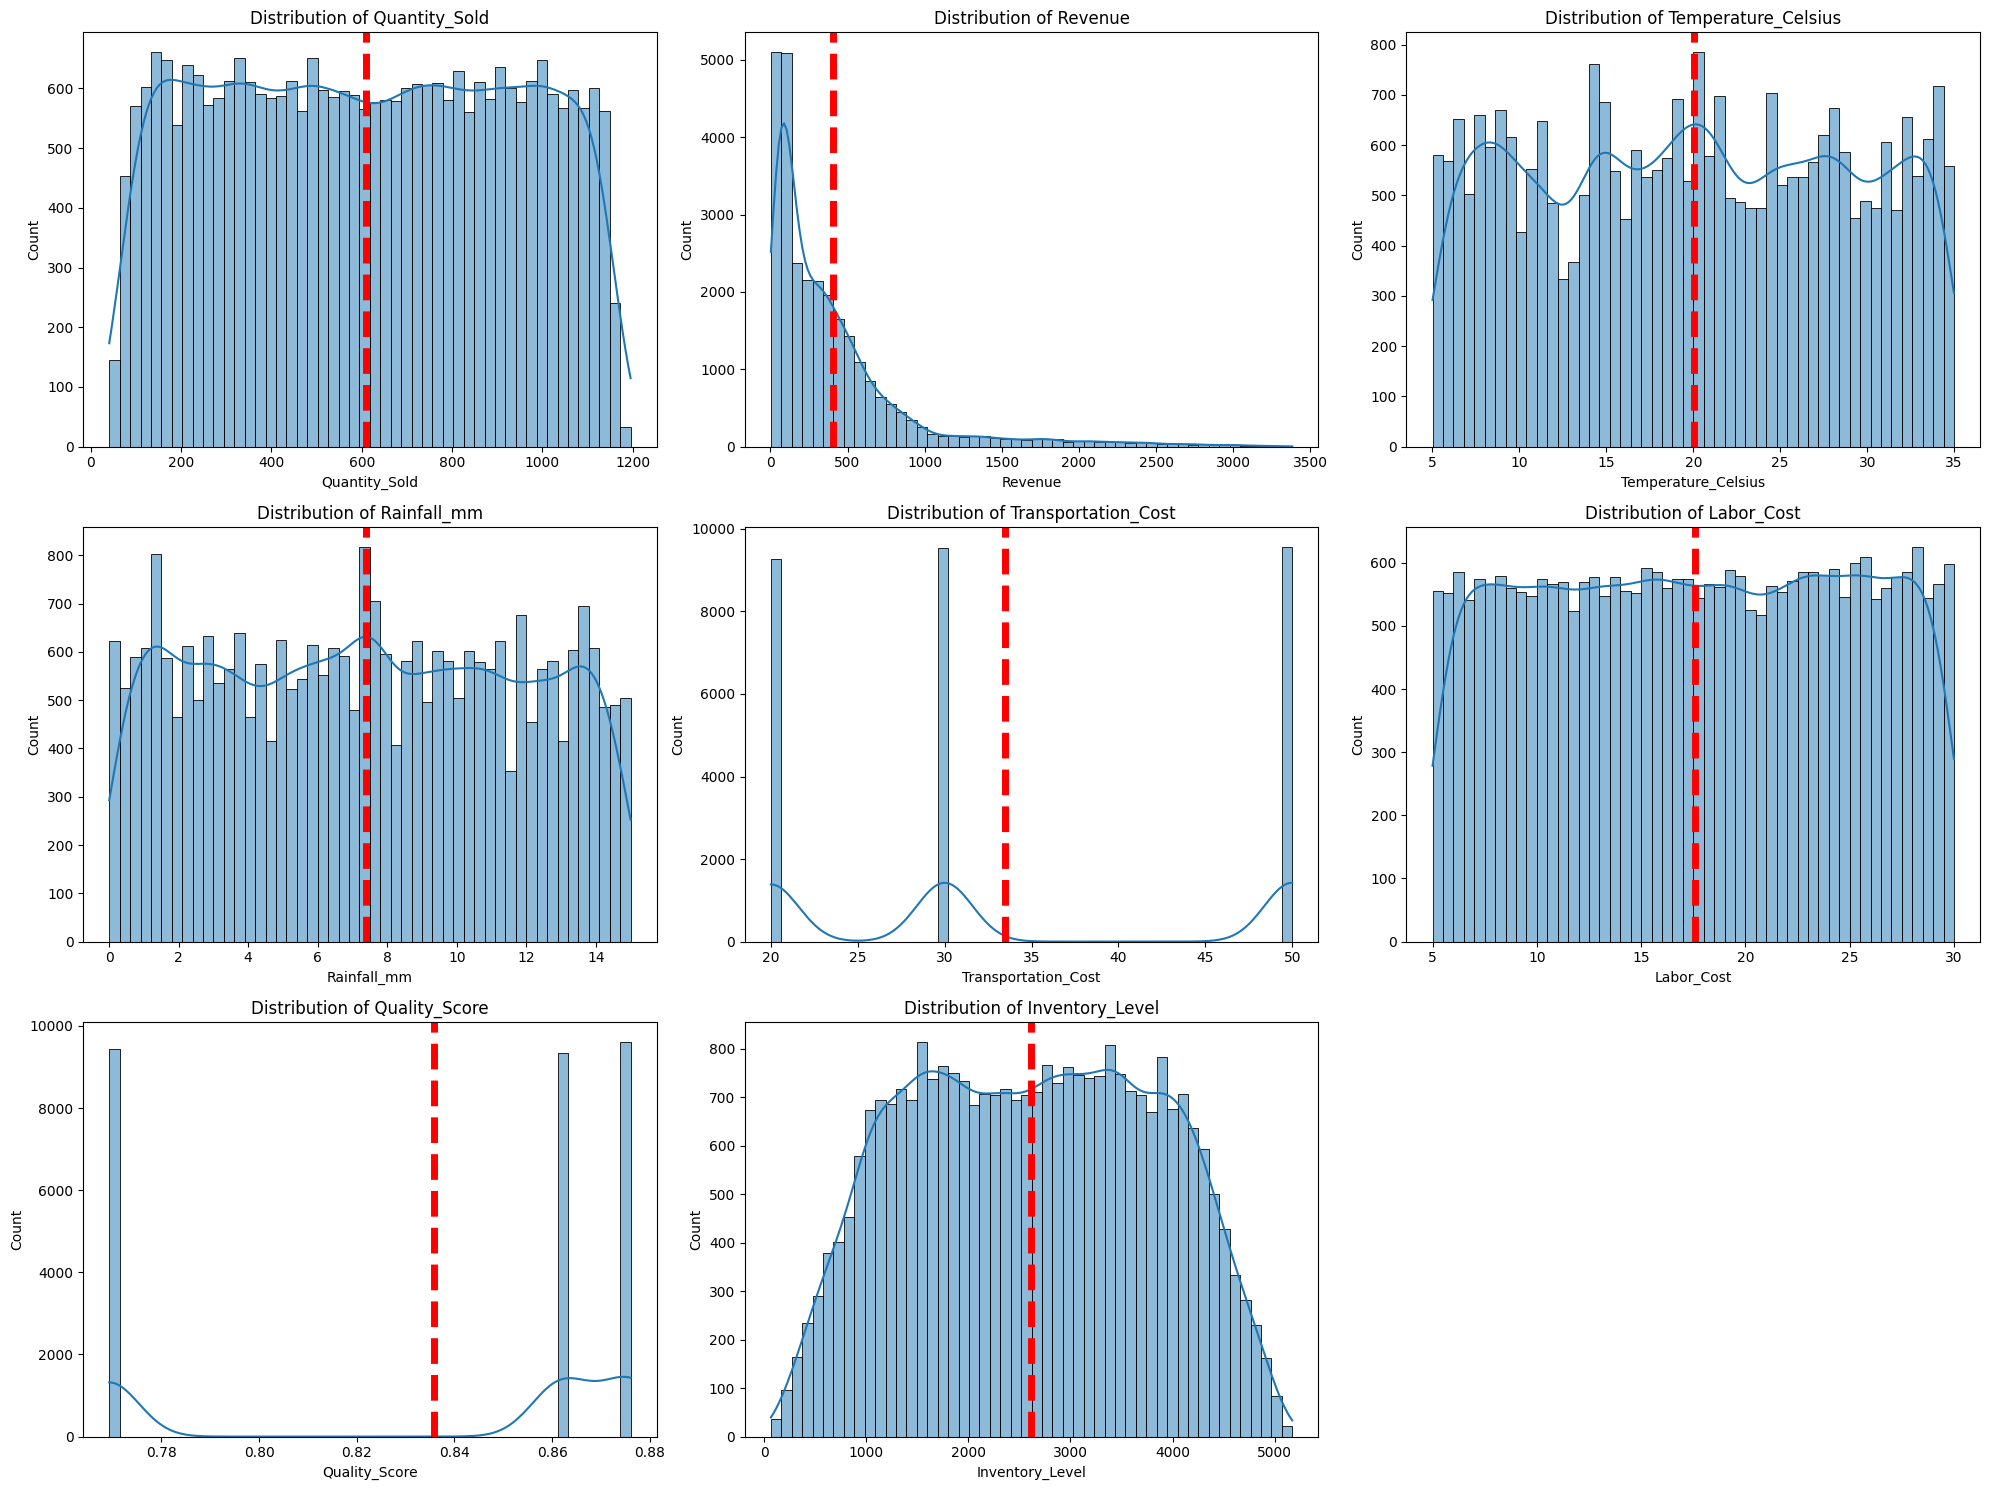

In [ ]:
plt.figure(figsize=(20, 15))

numerical_vars = df.select_dtypes(include=['float64', 'int64']).columns

# Boucle à travers chaque variable numérique pour créer des histogrammes
for i, var in enumerate(numerical_vars, 1):
    # Crée un sous-graphe dans une grille de 3x3, indexée par i
    plt.subplot(3, 3, i)

    # Trace un histogramme avec une courbe de densité pour la variable var
    sns.histplot(df[var], kde=True, bins=50)

    # Ajoute une ligne verticale à la moyenne de la variable var
    plt.axvline(df[var].mean(), color='red', linestyle='--', linewidth=5)

    # Titre du sous-graphe
    plt.title(f'Distribution of {var}')

# Ajuste l'espacement entre les sous-graphiques pour éviter le chevauchement
plt.tight_layout()

# Affiche les graphiques
plt.show()

# Ferme toutes les figures ouvertes pour libérer la mémoire
plt.close('all')


##Univariate Analysis: Categorical Variables

In [ ]:
df.columns

Index(['Date', 'Product', 'Quantity_Sold', 'Revenue', 'Temperature_Celsius',
       'Rainfall_mm', 'Location', 'Transportation_Cost', 'Labor_Cost',
       'Customer', 'Quality_Score', 'Inventory_Level'],
      dtype='object')

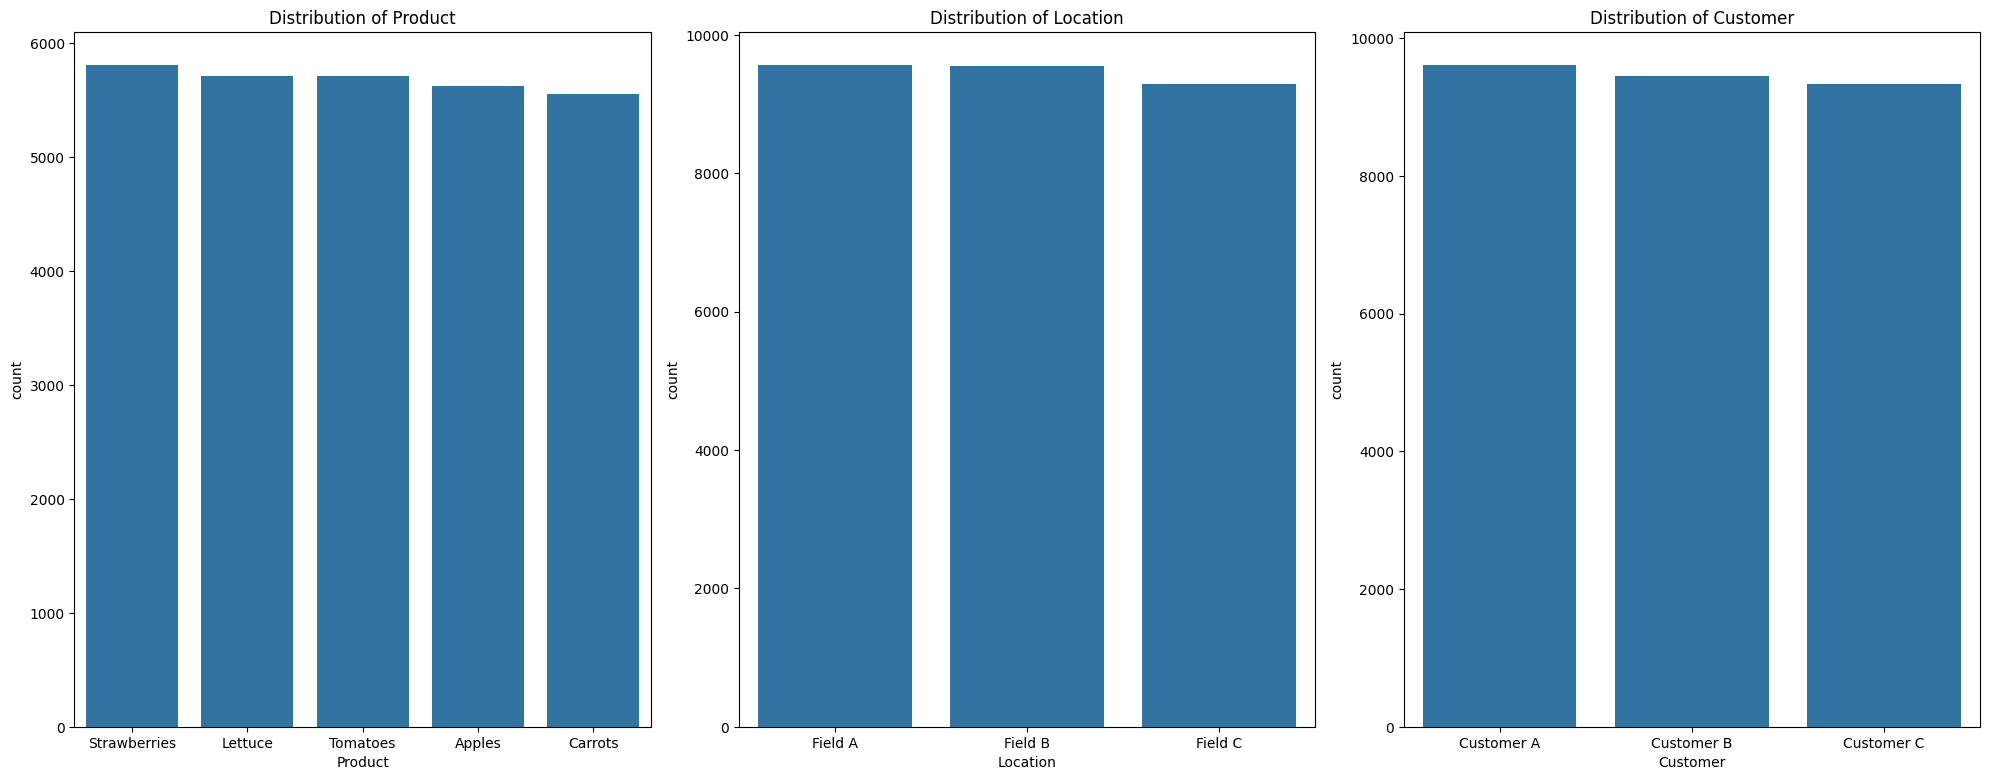

In [ ]:
plt.figure(figsize=(20, 15))

categorical_vars = df.select_dtypes(include=['object']).drop(columns=['Date'], axis=1).columns

# Boucle à travers chaque variable catégorique
for i, var in enumerate(categorical_vars, 1):
    # Crée un sous-graphe dans une grille de 3x3, indexée par i
    plt.subplot(2, 3, i)

    # Trace un graphique de comptage pour la variable var
    sns.countplot(x=var, data=df, order=df[var].value_counts().index)

    # Titre du sous-graphe
    plt.title(f'Distribution of {var}')

# Ajuste l'espacement entre les sous-graphiques pour éviter le chevauchement
plt.tight_layout()

# Affiche les graphiques
plt.show()

# Ferme toutes les figures ouvertes pour libérer la mémoire
plt.close('all')

##Bivariate  Analysis

We look  at pairs of variables to understand their relationships, by looking at :

    -   Pairs of Numerical variables

    -   Numerical and Categorical variables

    -   Pairs of Categorical variables

    

## Bivariate Analysis: Numerical Variables

Starting with plotting  a correlation matrix

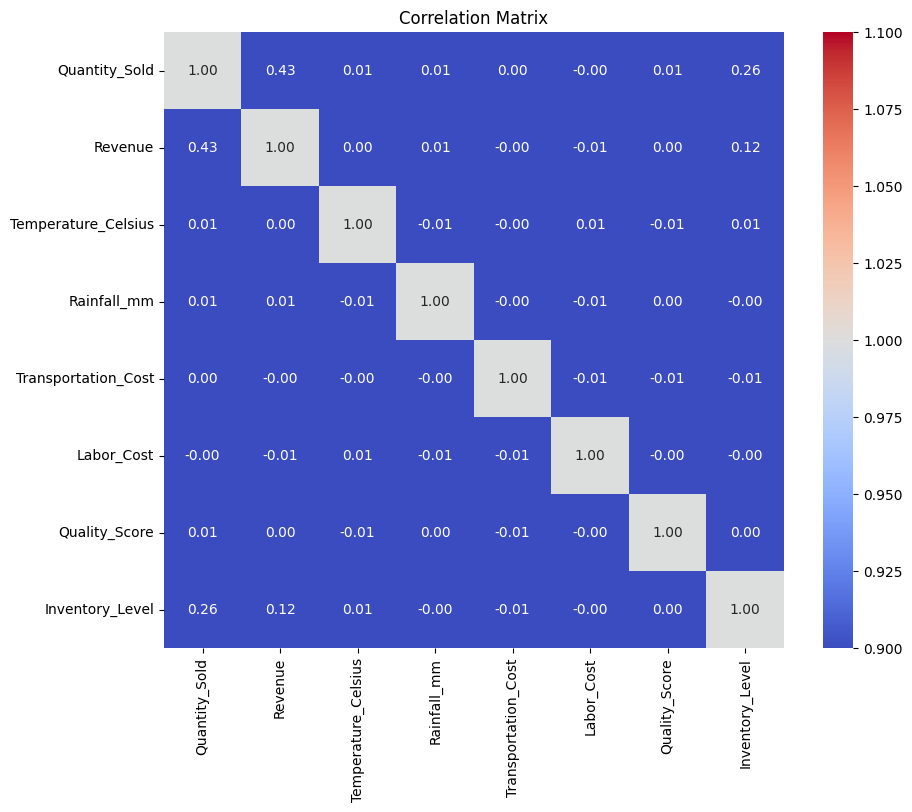

In [ ]:

correlation_matrix = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin= 1, vmax = 1)
plt.title('Correlation Matrix')
plt.show()
plt.close('all')

## Bivariate Analysis : Numerical and Categorical  Variables

We begin  by analysing  `Product` against:

    - `Revenue`

    - `Quantity_Sold`

    - `Quality_Score`


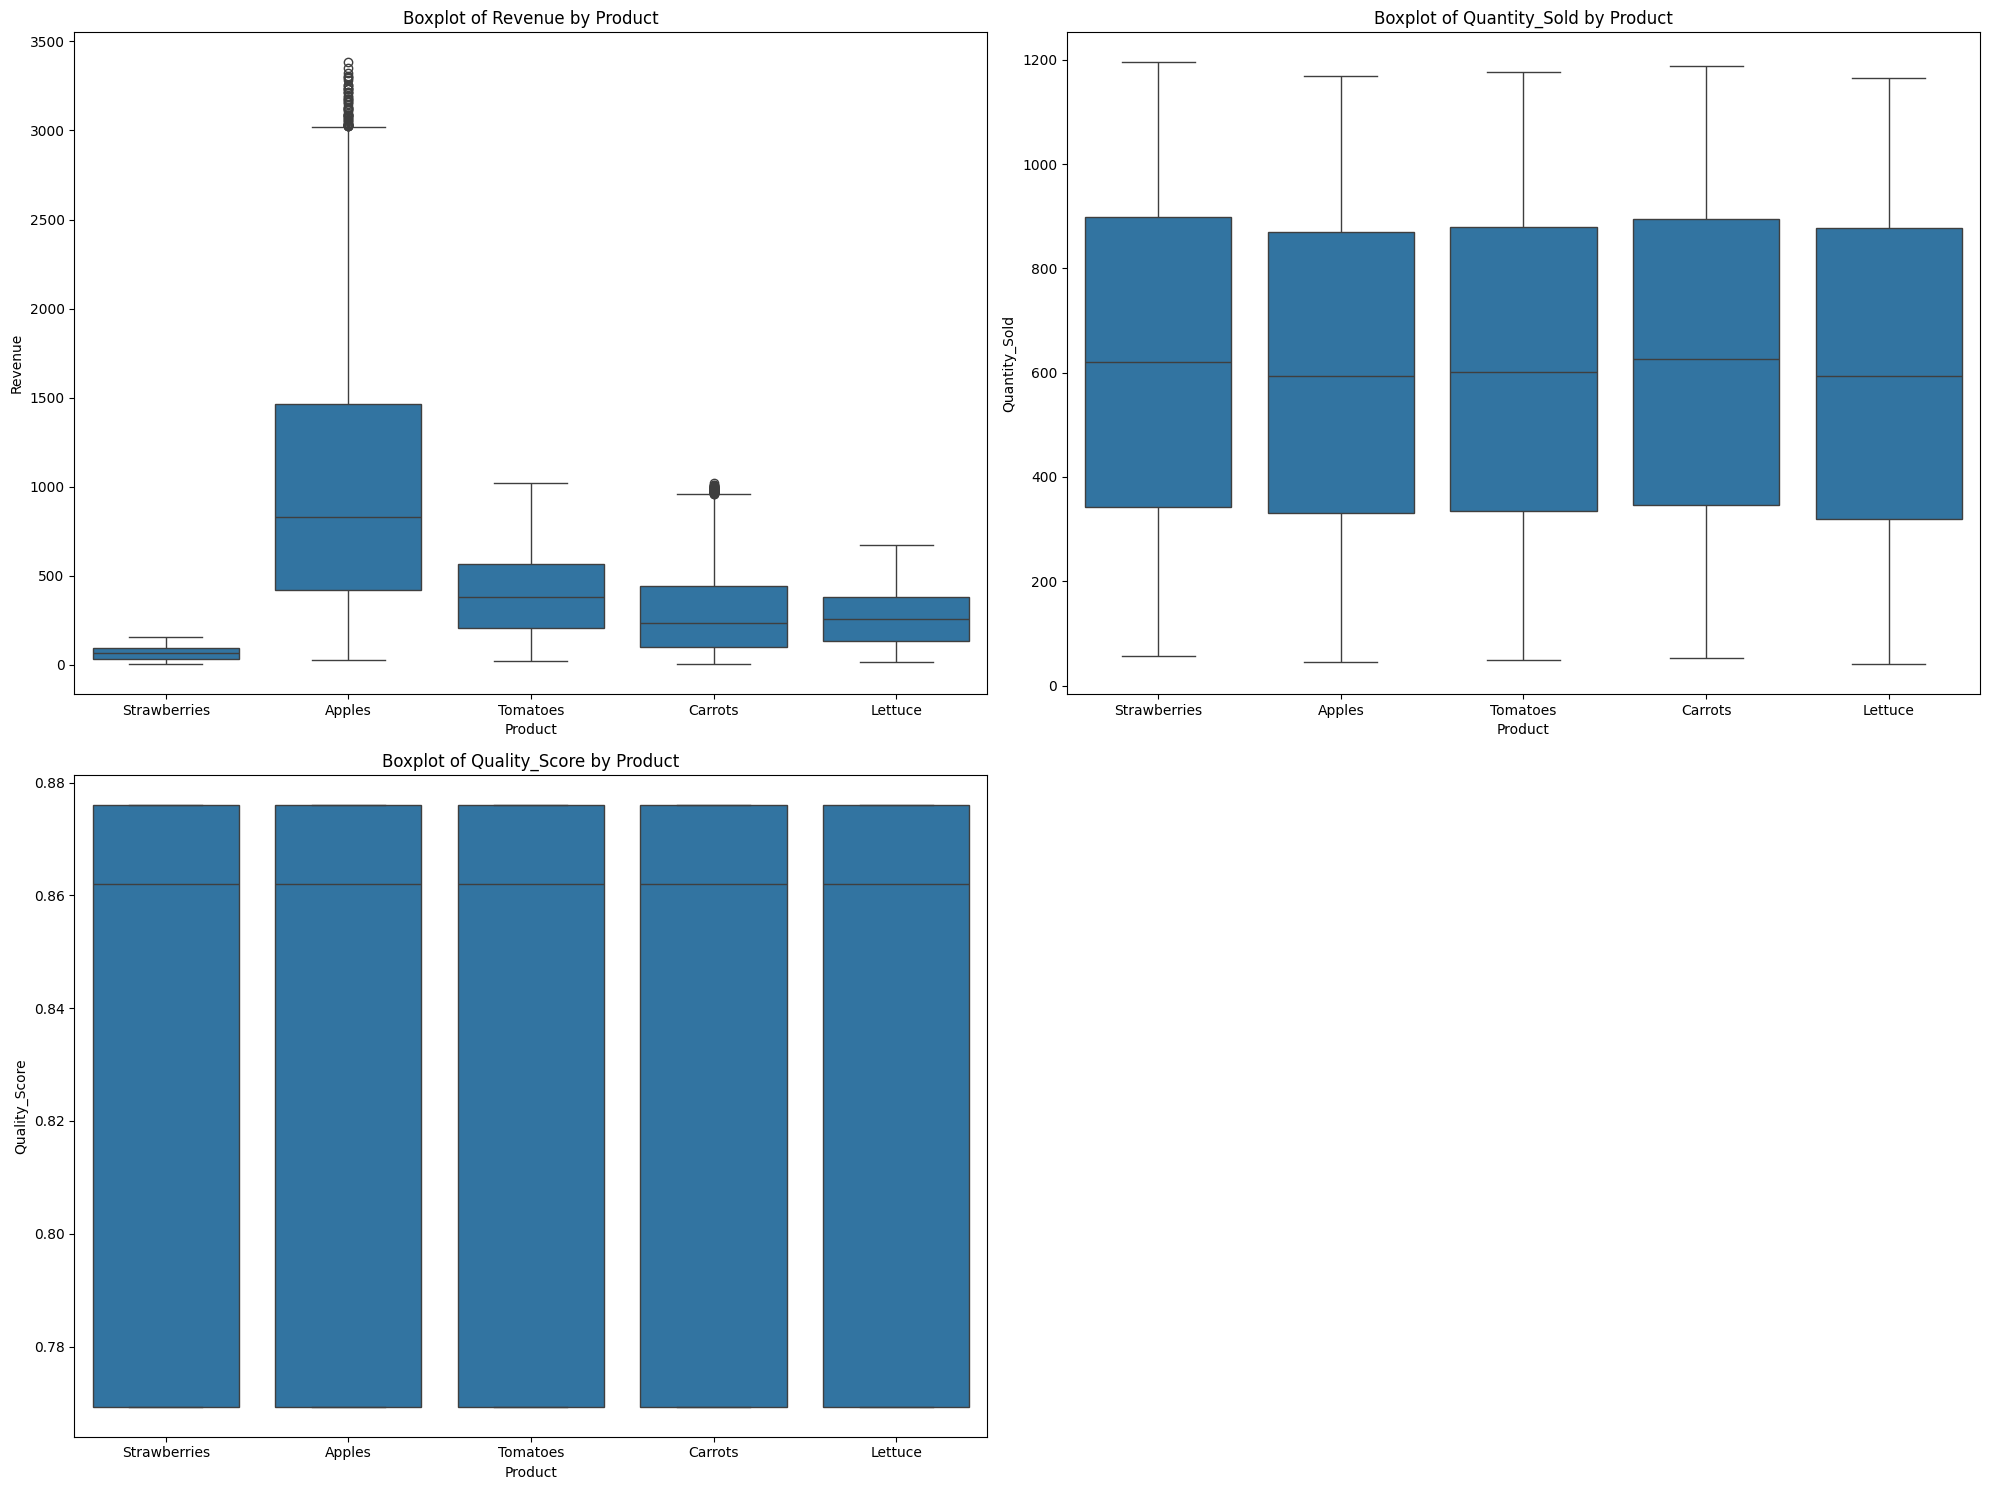

In [ ]:
plt.figure(figsize=(20, 15))

key_numerical_vars = ['Revenue', 'Quantity_Sold', 'Quality_Score']

for i, var in enumerate(key_numerical_vars, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Product', y=var, data=df)
    plt.title(f'Boxplot of {var} by Product')

plt.tight_layout()
plt.show()
plt.close('all')


In [ ]:
df.columns

Index(['Date', 'Product', 'Quantity_Sold', 'Revenue', 'Temperature_Celsius',
       'Rainfall_mm', 'Location', 'Transportation_Cost', 'Labor_Cost',
       'Customer', 'Quality_Score', 'Inventory_Level'],
      dtype='object')

We look at `Field` vs the same key numerical variables

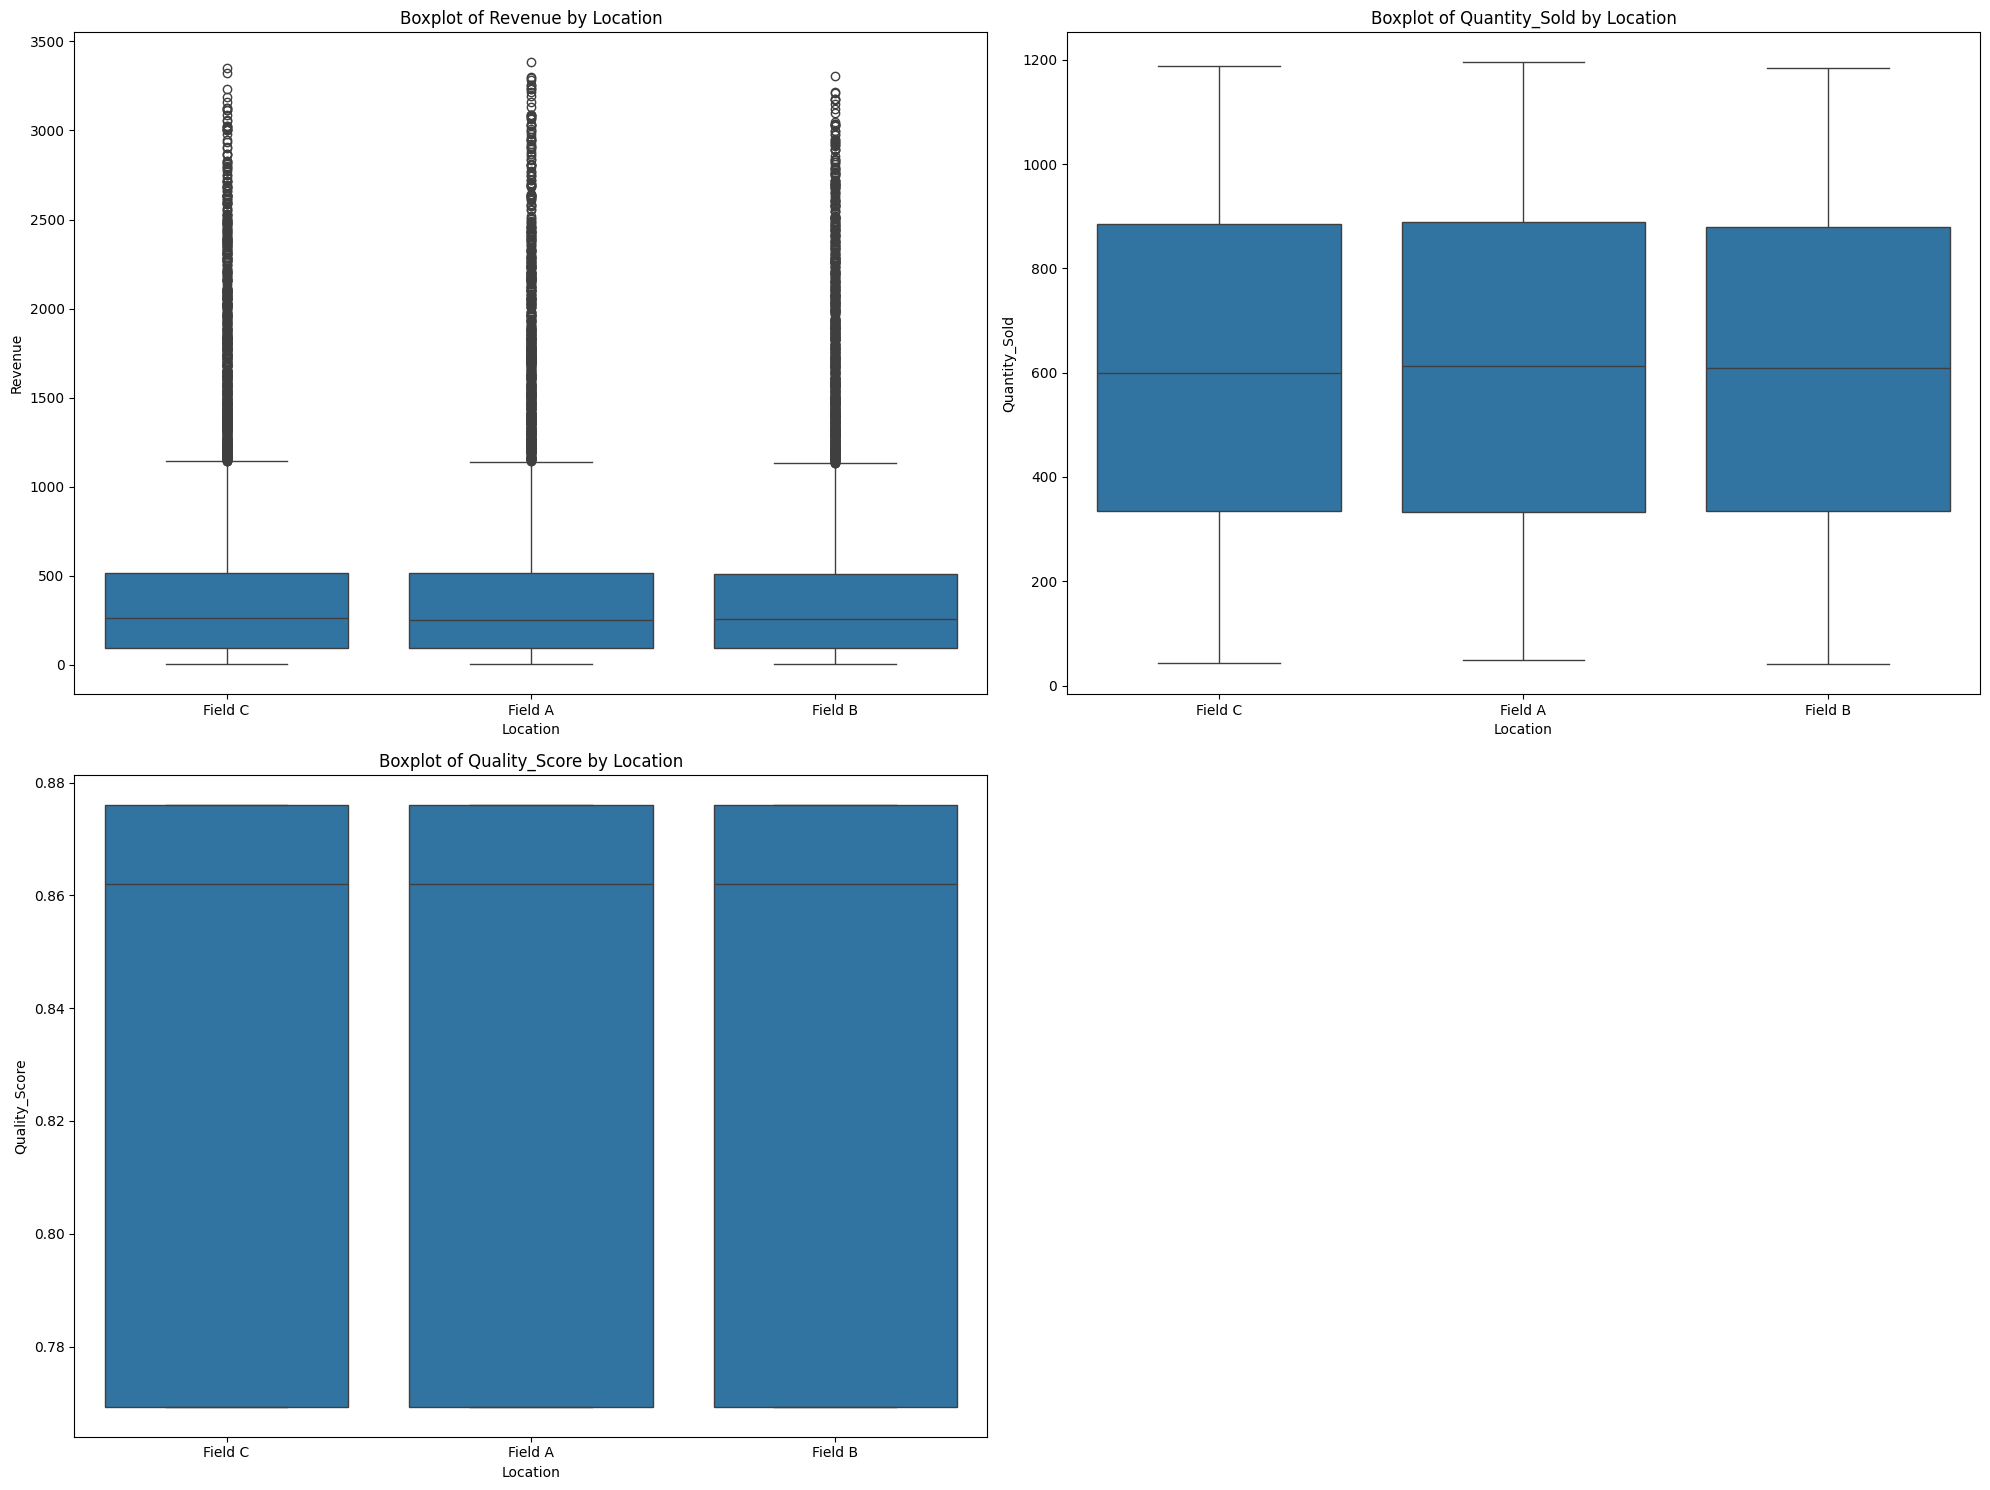

In [ ]:
plt.figure(figsize=(20, 15))


for i, var in enumerate(key_numerical_vars, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Location', y=var, data=df)
    plt.title(f'Boxplot of {var} by Location')

plt.tight_layout()
plt.show()
plt.close('all')


We see the relationships between `Customer` and the key numerical variables

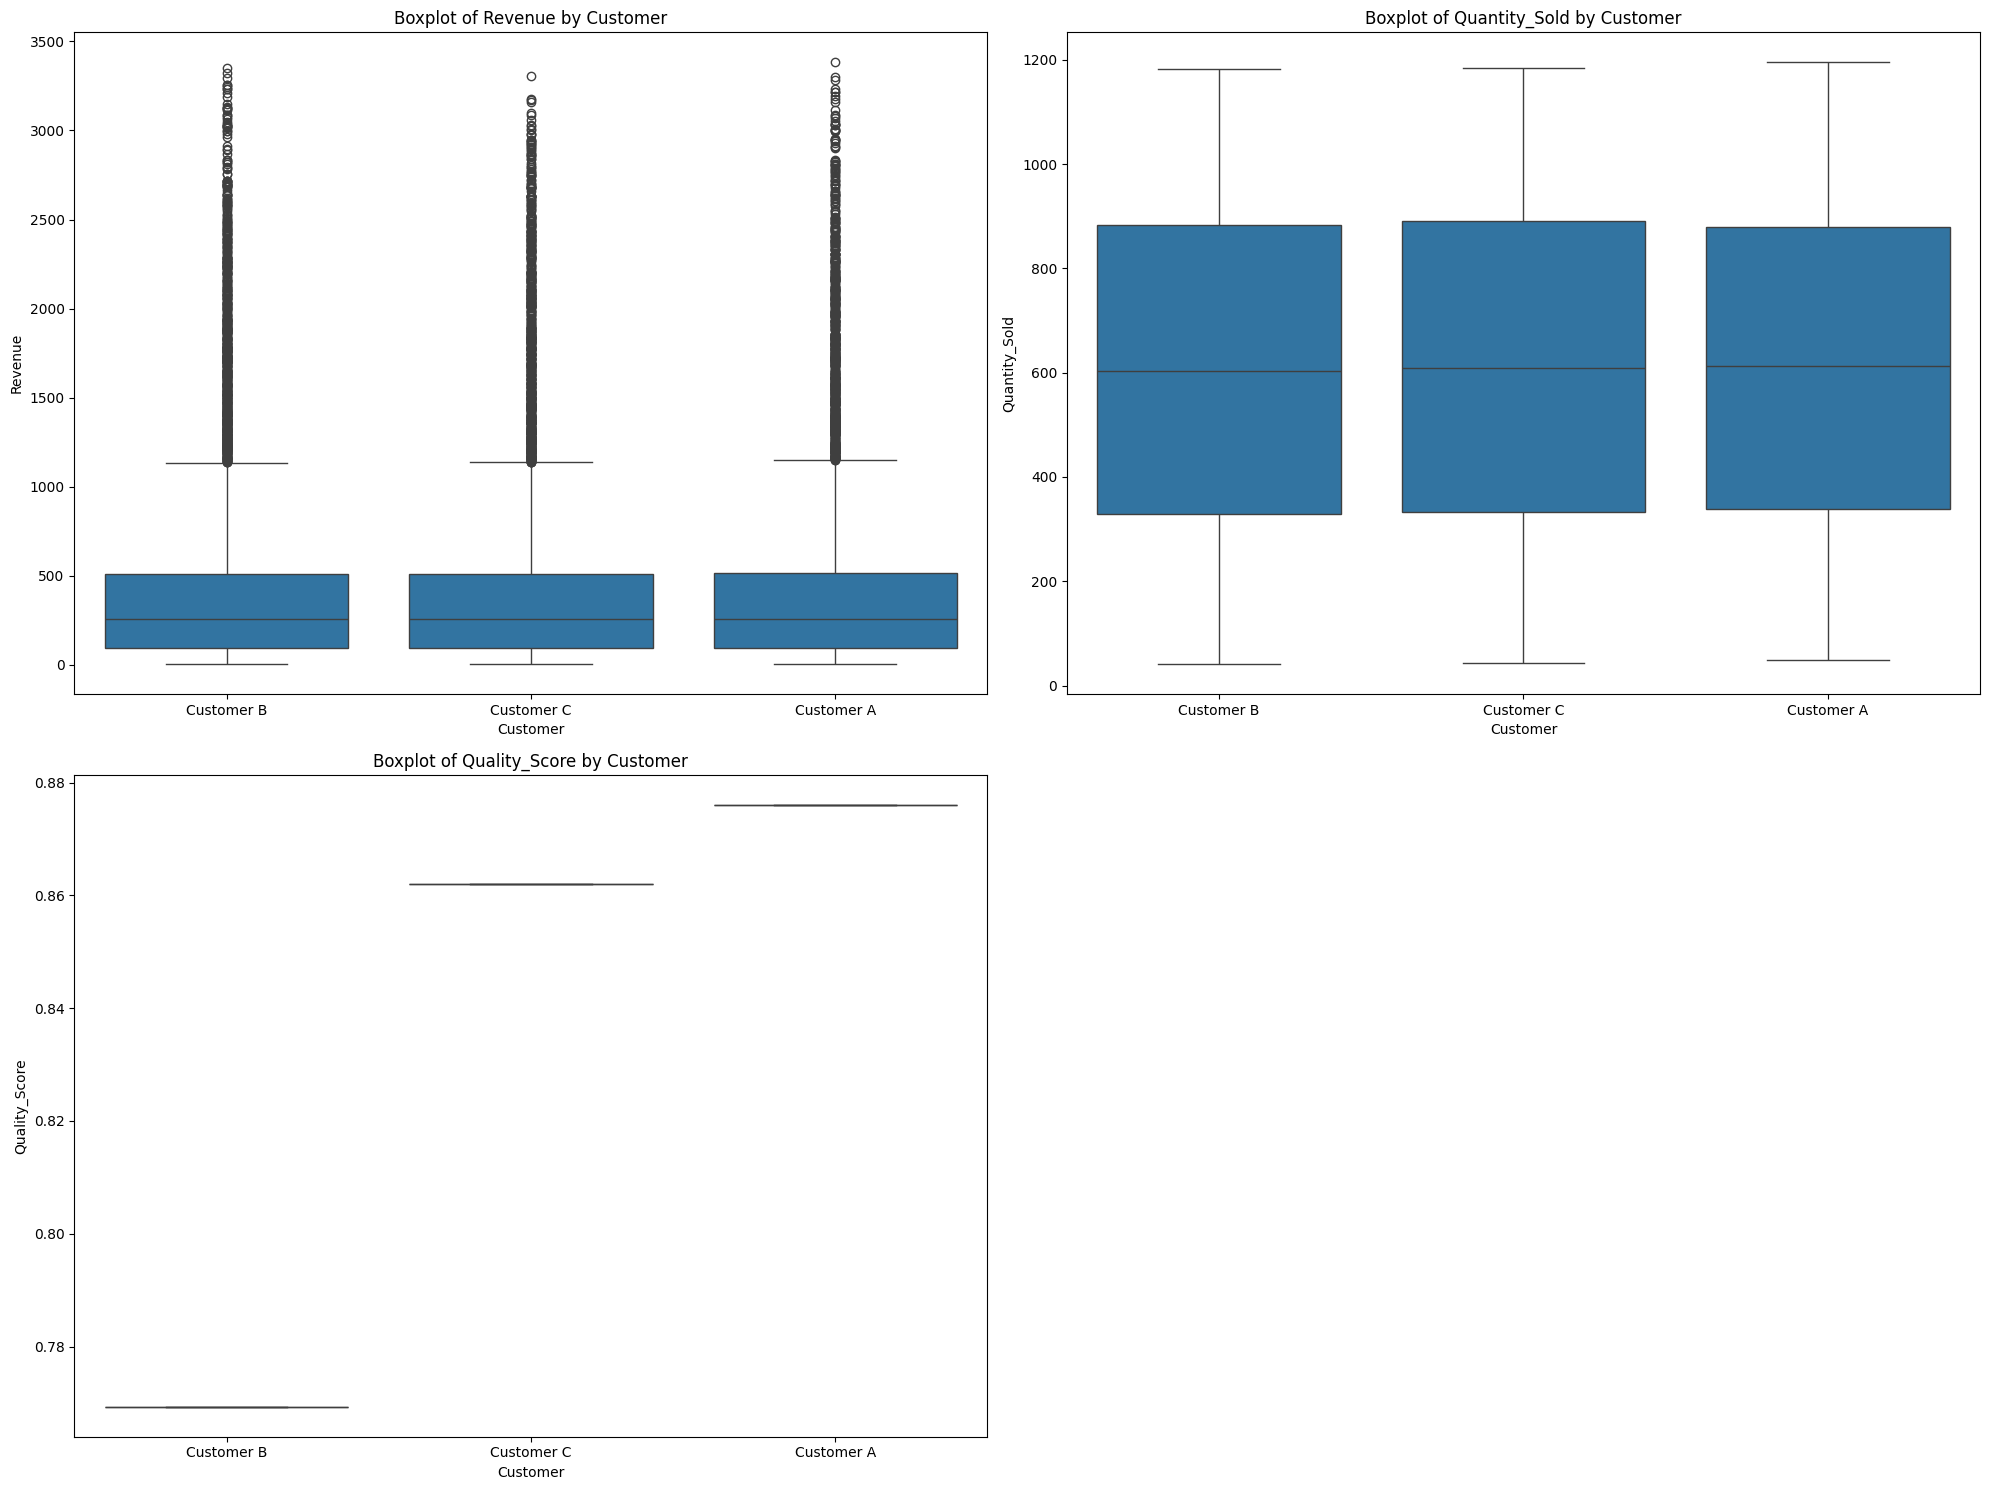

In [ ]:
plt.figure(figsize=(20, 15))


for i, var in enumerate(key_numerical_vars, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Customer', y=var, data=df)
    plt.title(f'Boxplot of {var} by Customer')

plt.tight_layout()
plt.show()
plt.close('all')


Next, we visualize :

  - Total `Quantity_Sold` per 'Product'

  - Total `Revenue` per 'Product'

  - `Quality_Score` per 'Product'

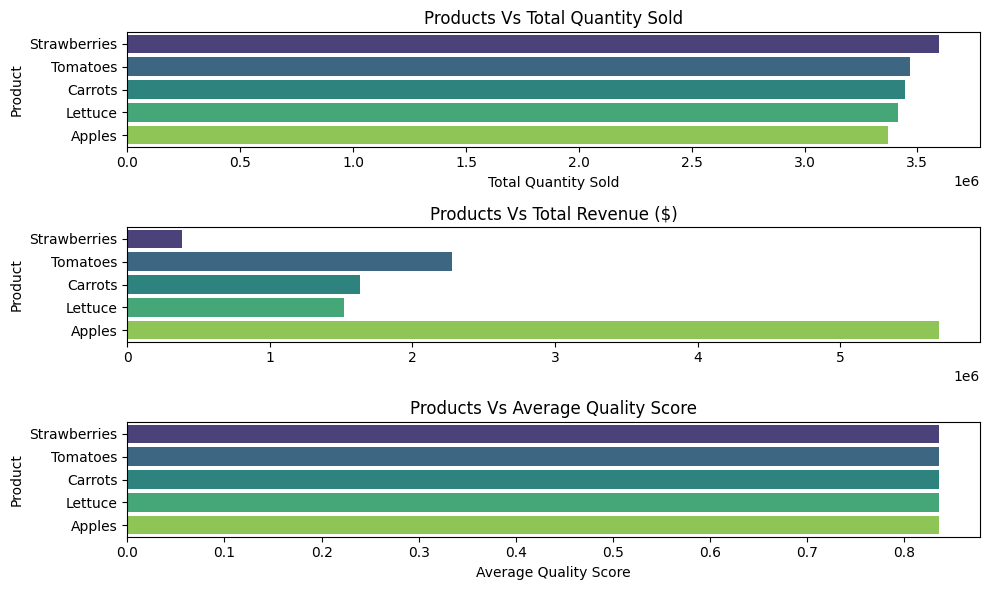

In [ ]:
# Agréger les données par produit, en calculant la somme des quantités vendues, la somme des revenus,
# et la moyenne des scores de qualité
product_data = df.groupby('Product').agg({
    'Quantity_Sold': 'sum',  # Somme des quantités vendues par produit
    'Revenue': 'sum',  # Somme des revenus par produit
    'Quality_Score': 'mean'  # Moyenne des scores de qualité par produit
}).reset_index()  # Réinitialisation des index pour obtenir un DataFrame plat

# Trier les données agrégées par quantité vendue en ordre décroissant
product_data = product_data.sort_values(by='Quantity_Sold', ascending=False)

# Créer une figure avec trois sous-graphes empilés verticalement
fig, ax = plt.subplots(3, 1, figsize=(10, 6))

# Graphique 1 : Produit vs Quantité Totale Vendue
sns.barplot(y='Product', x='Quantity_Sold', data=product_data, ax=ax[0], palette='viridis')
ax[0].set_title('Products Vs Total Quantity Sold')  # Titre du graphique
ax[0].set_xlabel('Total Quantity Sold')  # Label de l'axe x
ax[0].set_ylabel('Product')  # Label de l'axe y

# Graphique 2 : Produit vs Revenu Total
sns.barplot(y='Product', x='Revenue', data=product_data, ax=ax[1], palette='viridis')
ax[1].set_title('Products Vs Total Revenue ($)')  # Titre du graphique
ax[1].set_xlabel('')  # On laisse l'axe x sans label car il est partagé avec le graphique précédent
ax[1].set_ylabel('Product')  # Label de l'axe y

# Graphique 3 : Produit vs Score Moyen de Qualité
sns.barplot(y='Product', x='Quality_Score', data=product_data, ax=ax[2], palette='viridis')
ax[2].set_title('Products Vs Average Quality Score')  # Titre du graphique
ax[2].set_xlabel('Average Quality Score')  # Label de l'axe x
ax[2].set_ylabel('Product')  # Label de l'axe y

# Ajuster l'espacement entre les sous-graphes pour une meilleure présentation
plt.tight_layout()

# Afficher la figure à l'écran
plt.show()

# Fermer toutes les figures ouvertes pour libérer la mémoire
plt.close('all')

Next,  we see  the  total Quality  Sold for each  product per Customer

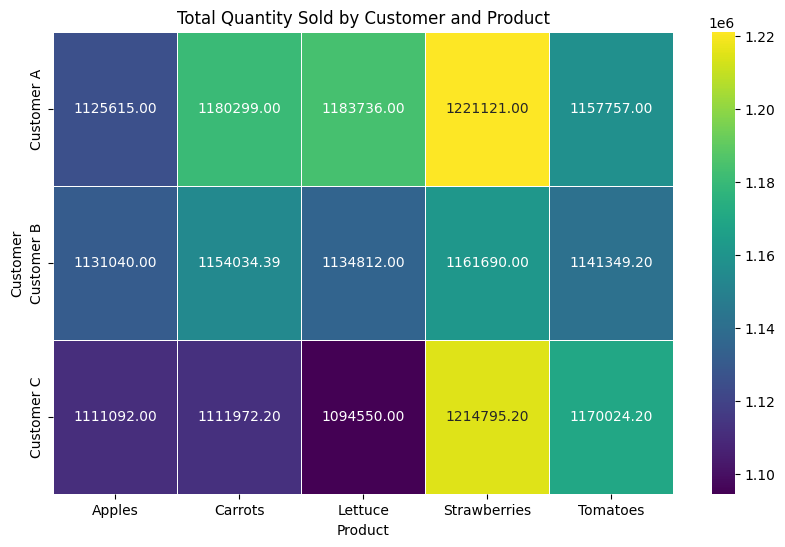

In [ ]:
# Agréger les données par client et produit, en calculant la somme des quantités vendues et des revenus,
# ainsi que la moyenne des scores de qualité
customer_data = df.groupby(['Customer', 'Product']).agg({
    'Quantity_Sold': 'sum',  # Somme des quantités vendues
    'Revenue': 'sum',  # Somme des revenus
    'Quality_Score': 'mean'  # Moyenne des scores de qualité
}).reset_index()  # Réinitialisation des index pour obtenir un DataFrame plat

# Créer un tableau croisé dynamique (pivot table) pour les quantités vendues par client et par produit
customer_pivot = customer_data.pivot(index='Customer', columns='Product', values='Quantity_Sold')

# Configurer la taille de la figure pour le graphique
plt.figure(figsize=(10, 6))

# Créer la heatmap en utilisant les données pivotées
sns.heatmap(customer_pivot, cmap='viridis', annot=True, fmt='.2f', linewidths=0.5)

# Ajouter un titre au graphique
plt.title('Total Quantity Sold by Customer and Product')

# Ajouter un label à l'axe des x (produits)
plt.xlabel('Product')

# Ajouter un label à l'axe des y (clients)
plt.ylabel('Customer')

# Afficher la figure à l'écran
plt.show()

# Fermer toutes les figures pour libérer la mémoire
plt.close('all')

##Bivariate Analysis :  Two Categorical   Variables

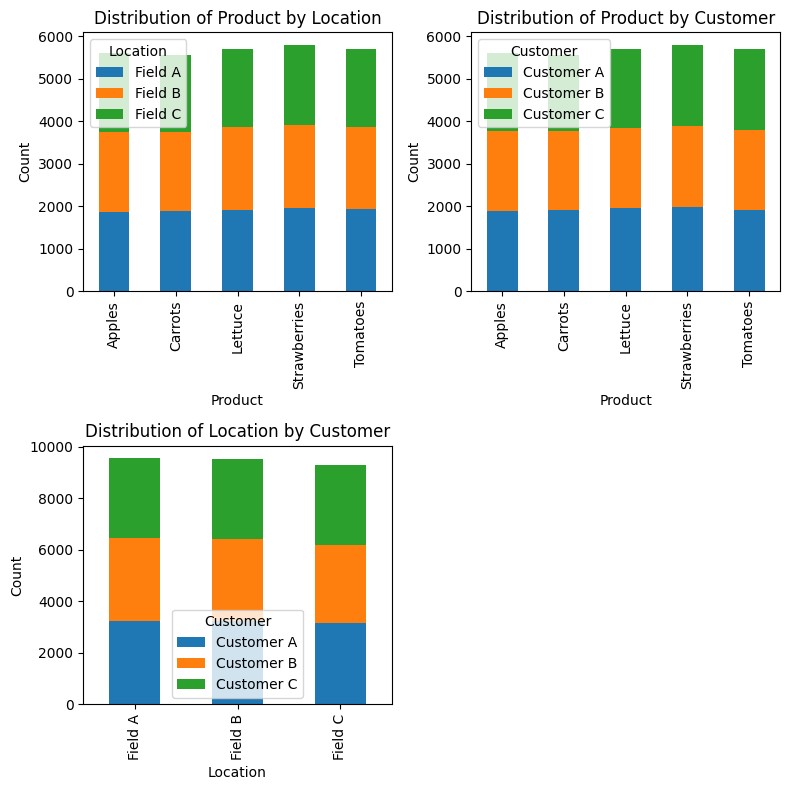

In [ ]:
plt.figure(figsize=(8, 8))

pairs = [
    ("Product", "Location"),
    ("Product", "Customer"),
    ("Location", "Customer")
]

for i, (p1, p2) in enumerate(pairs):
    contingency_table = pd.crosstab(df[p1], df[p2])
    ax = plt.subplot(2, 2, i+1)
    contingency_table.plot(kind='bar', stacked=True, ax=ax)

    plt.title(f"Distribution of {p1} by {p2}")
    plt.ylabel('Count')
    plt.xlabel(p1)

plt.tight_layout()
plt.show()
plt.close('all')

## Multivariate   Analysis

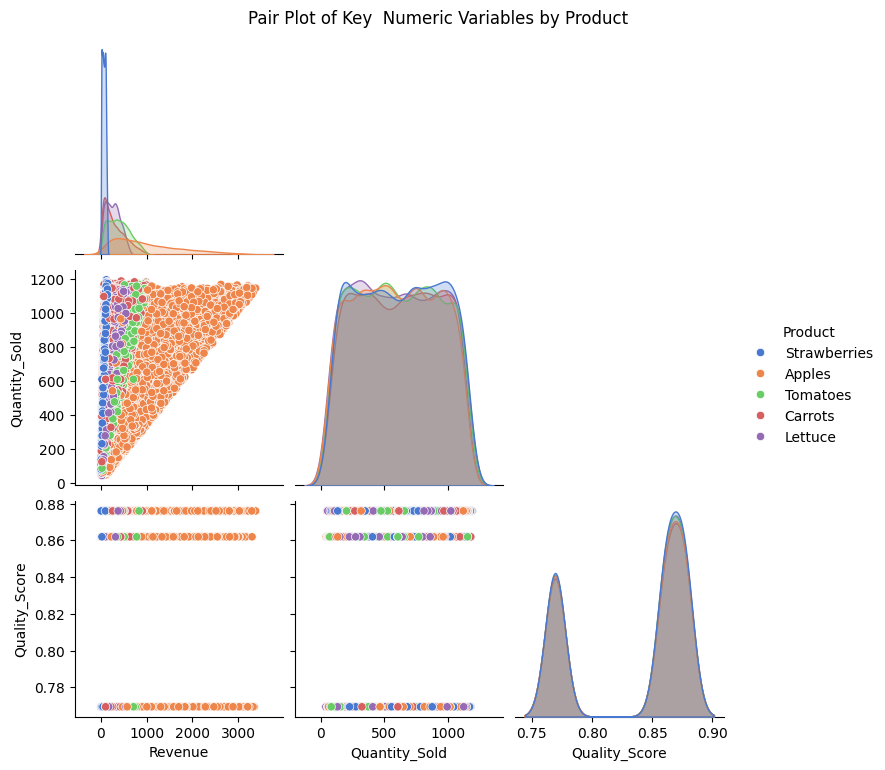

In [ ]:

pair_plot = sns.pairplot(df, hue='Product', corner=True, vars=key_numerical_vars, palette='muted')

pair_plot.fig.suptitle("Pair Plot of Key  Numeric Variables by Product", y=1.02)

plt.show()
plt.close('all')

##Temporal Analysis

How  the `Quantity_Sold` and `Revenue` vary dailly

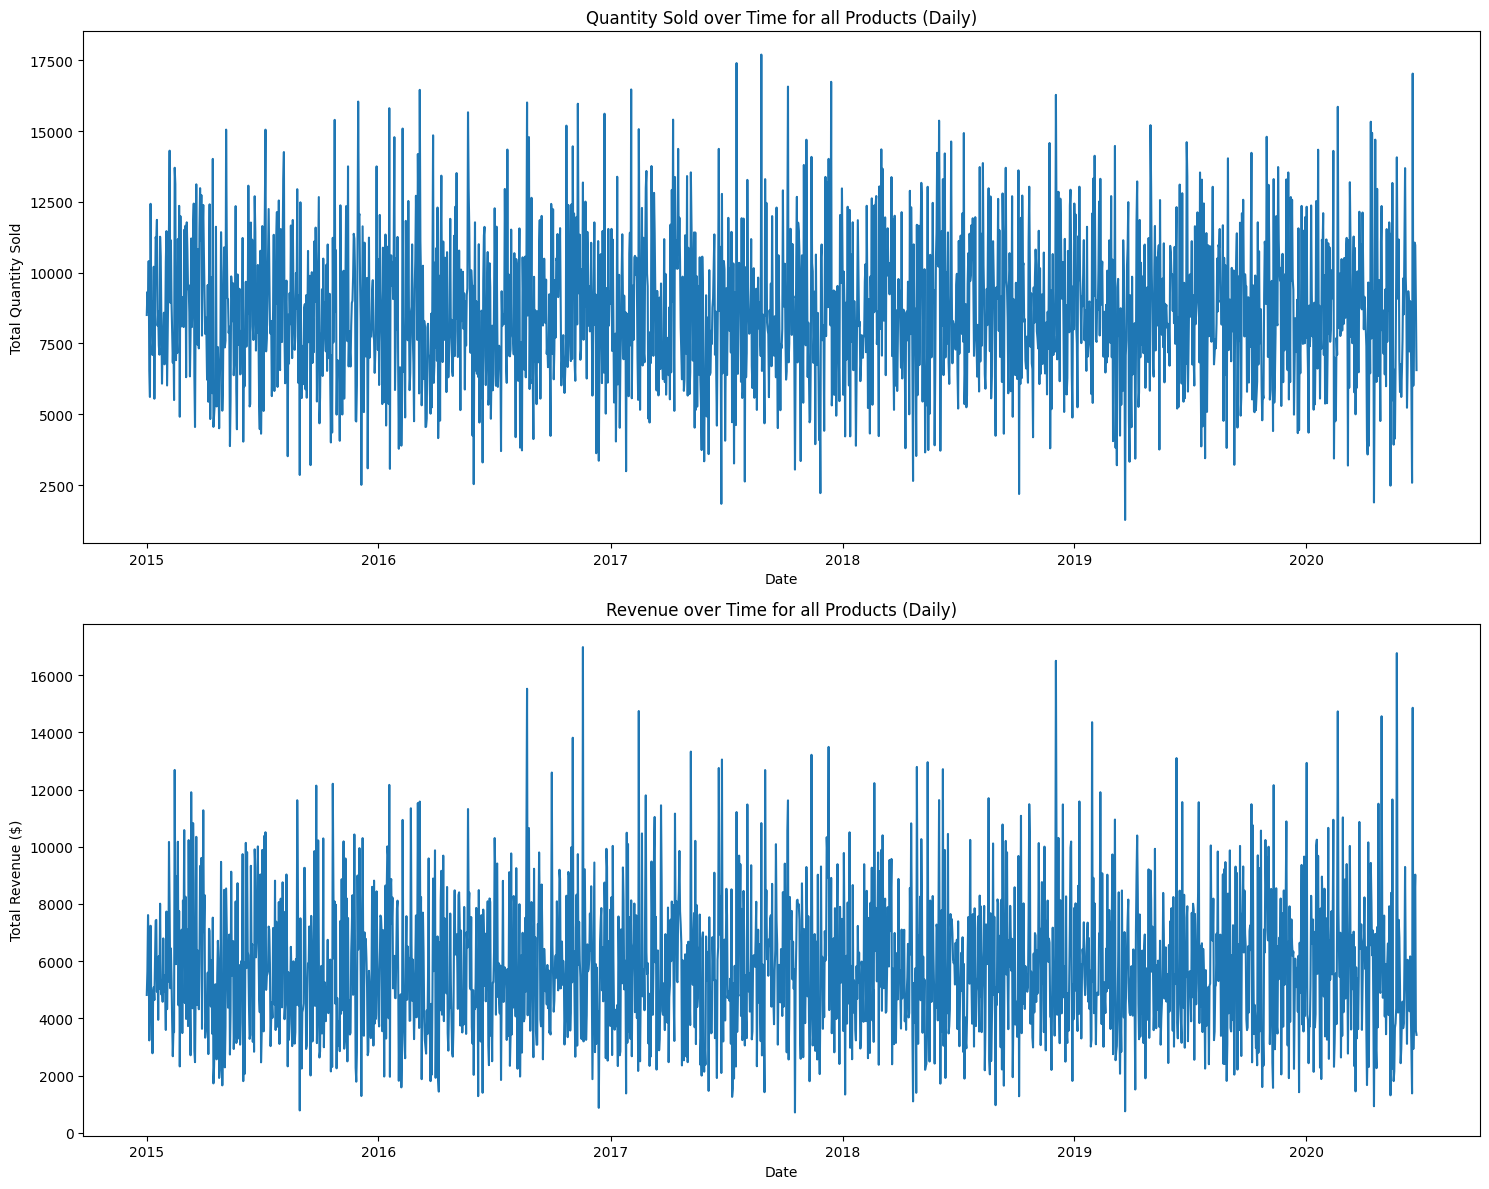

In [ ]:
# Conversion de la colonne 'Date' en type datetime pour permettre la manipulation temporelle
df['Date'] = pd.to_datetime(df['Date'])

# Agréger les données par date, en calculant la somme des quantités vendues et des revenus
time_based_data = df.groupby('Date').agg({
    'Quantity_Sold': 'sum',  # Somme des quantités vendues par date
    'Revenue': 'sum'  # Somme des revenus par date
}).reset_index()  # Réinitialisation des index pour obtenir un DataFrame plat

# Créer une figure avec deux sous-graphes empilés verticalement
fig, ax = plt.subplots(2, 1, figsize=(15, 12))

# Graphique 1 : Quantité Totale Vendue au fil du temps (journalier)
sns.lineplot(x='Date', y='Quantity_Sold', data=time_based_data, ax=ax[0])
ax[0].set_title('Quantity Sold over Time for all Products (Daily)')  # Titre du graphique
ax[0].set_xlabel('Date')  # Label de l'axe x
ax[0].set_ylabel('Total Quantity Sold')  # Label de l'axe y

# Graphique 2 : Revenu Total au fil du temps (journalier)
sns.lineplot(x='Date', y='Revenue', data=time_based_data, ax=ax[1])
ax[1].set_title('Revenue over Time for all Products (Daily)')  # Titre du graphique
ax[1].set_xlabel('Date')  # Label de l'axe x
ax[1].set_ylabel('Total Revenue ($)')  # Label de l'axe y

# Ajuster l'espacement entre les sous-graphes pour une meilleure présentation
plt.tight_layout()

# Afficher la figure à l'écran
plt.show()

# Fermer toutes les figures ouvertes pour libérer la mémoire
plt.close('all')

Make the same plot  weekly

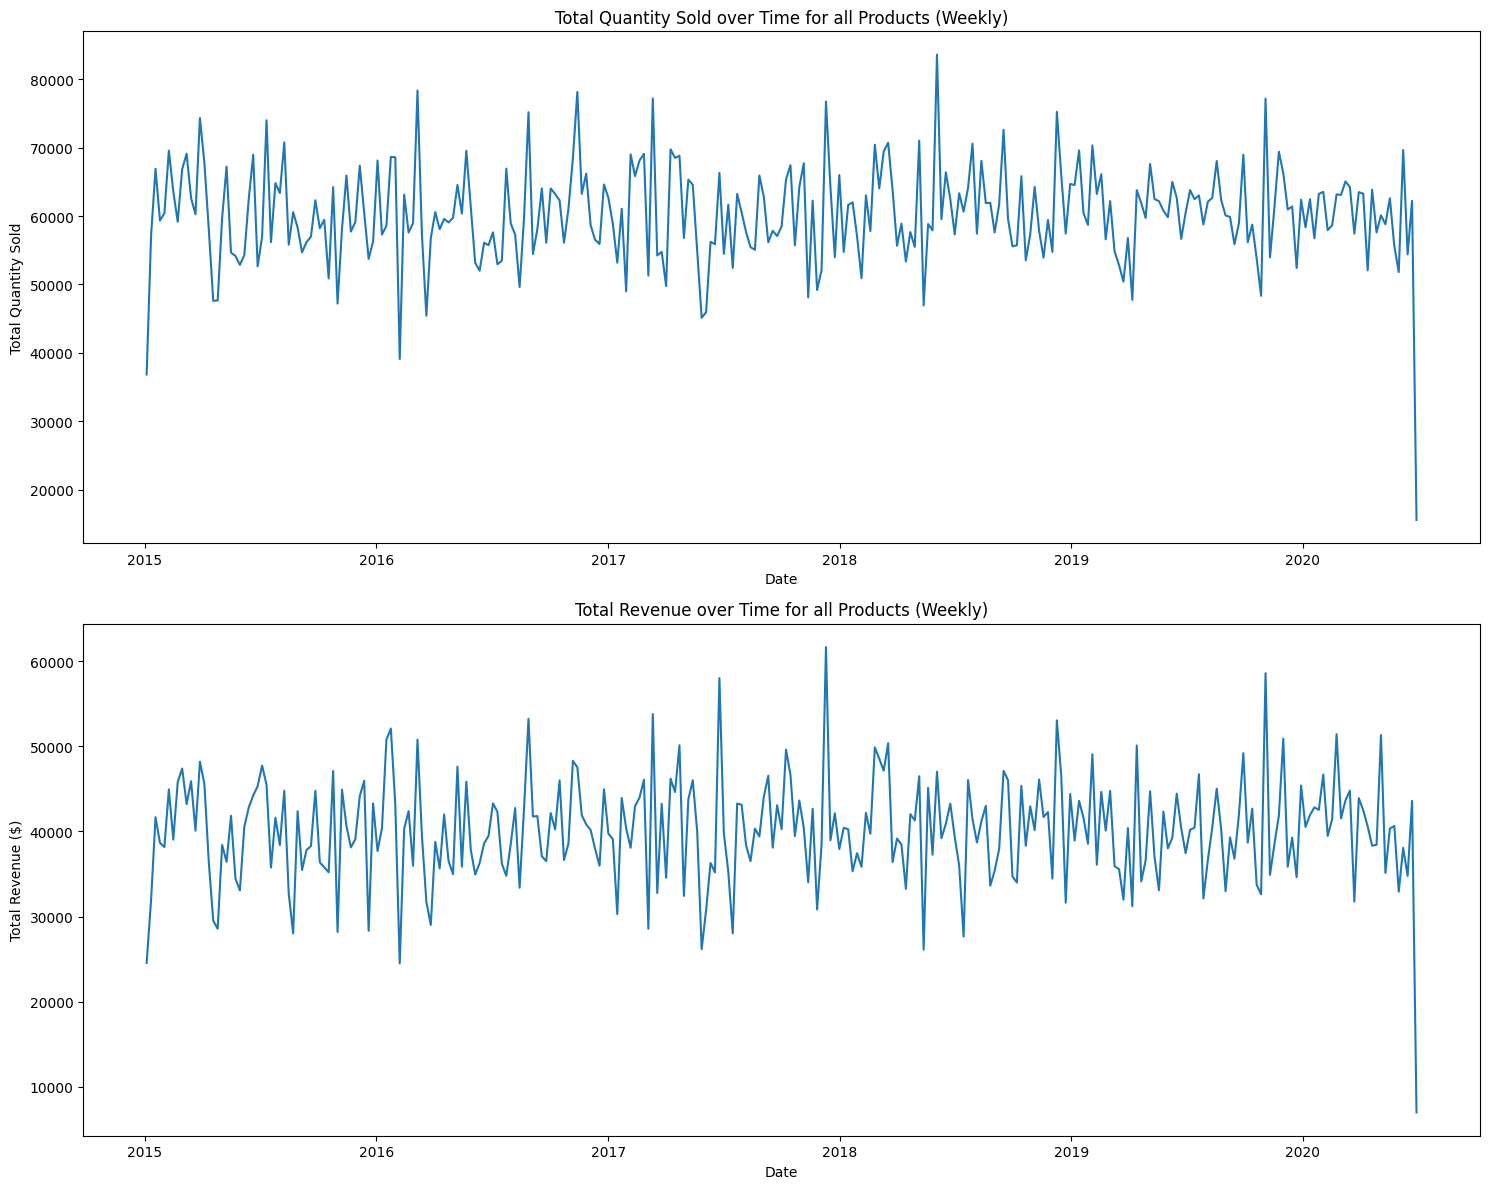

In [ ]:
# Agréger les données par date, en calculant la somme des quantités vendues et des revenus
time_based_data = df.groupby('Date').agg({
    'Quantity_Sold': 'sum',  # Somme des quantités vendues par date
    'Revenue': 'sum'  # Somme des revenus par date
}).reset_index()  # Réinitialisation des index pour obtenir un DataFrame plat

# Rééchantillonner les données par semaine et calculer la somme des quantités vendues et des revenus
time_based_data = time_based_data.set_index('Date').resample('W').sum().reset_index()

# Créer une figure avec deux sous-graphes empilés verticalement
fig, ax = plt.subplots(2, 1, figsize=(15, 12))

# Graphique 1 : Quantité Totale Vendue au fil du temps
sns.lineplot(x='Date', y='Quantity_Sold', data=time_based_data, ax=ax[0])
ax[0].set_title('Total Quantity Sold over Time for all Products (Weekly)')  # Titre du graphique
ax[0].set_xlabel('Date')  # Label de l'axe x
ax[0].set_ylabel('Total Quantity Sold')  # Label de l'axe y

# Graphique 2 : Revenu Total au fil du temps
sns.lineplot(x='Date', y='Revenue', data=time_based_data, ax=ax[1])
ax[1].set_title('Total Revenue over Time for all Products (Weekly)')  # Titre du graphique
ax[1].set_xlabel('Date')  # Label de l'axe x
ax[1].set_ylabel('Total Revenue ($)')  # Label de l'axe y

# Ajuster l'espacement entre les sous-graphes pour une meilleure présentation
plt.tight_layout()

# Afficher la figure à l'écran
plt.show()

# Fermer toutes les figures ouvertes pour libérer la mémoire
plt.close('all')

Make the same plot  monthly

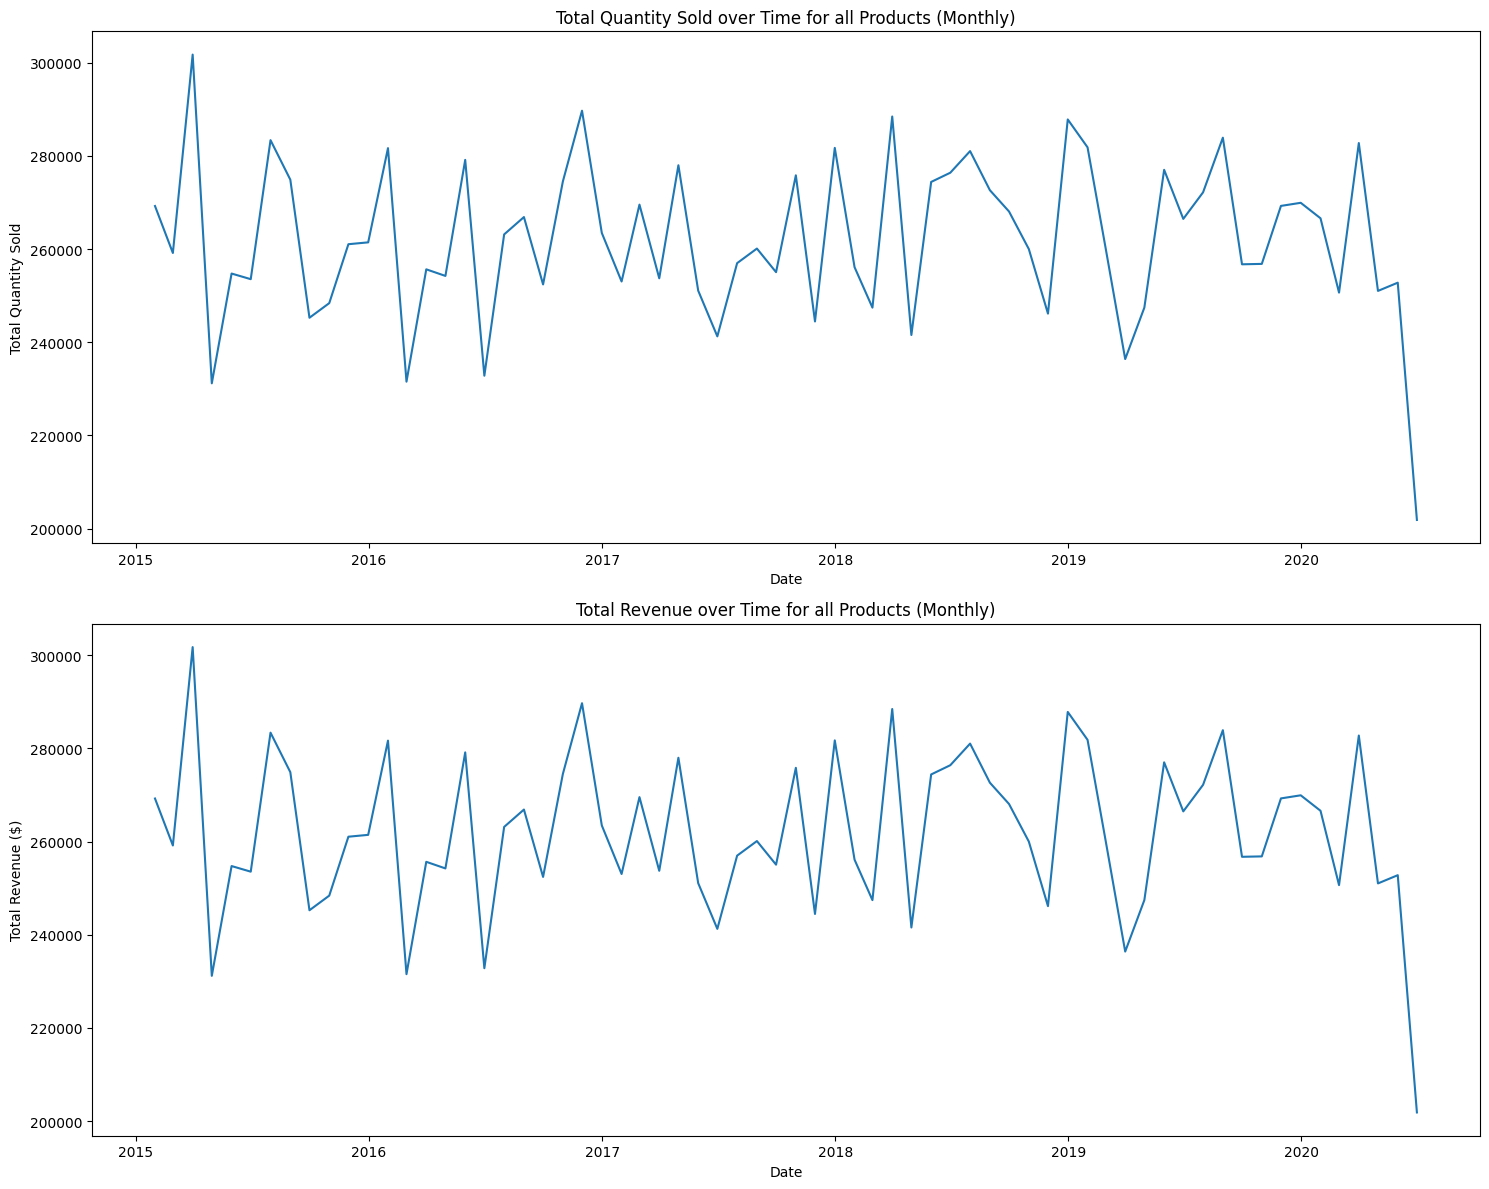

In [ ]:

time_based_data = df.groupby('Date').agg({
    'Quantity_Sold': 'sum',  # Somme des quantités vendues par date
    'Revenue': 'sum'  # Somme des revenus par date
}).reset_index()  # Réinitialisation des index pour obtenir un DataFrame

time_based_data = time_based_data.set_index('Date').resample('M').sum().reset_index()

fig, ax = plt.subplots(2, 1, figsize=(15, 12))

#
sns.lineplot(x='Date', y='Quantity_Sold', data=time_based_data, ax=ax[0])
ax[0].set_title('Total Quantity Sold over Time for all Products (Monthly)')  # Titre du graphique
ax[0].set_xlabel('Date')  # Label de l'axe x
ax[0].set_ylabel('Total Quantity Sold')  # Label de l'axe

#
sns.lineplot(x='Date', y='Quantity_Sold', data=time_based_data, ax=ax[1])
ax[1].set_title('Total Revenue over Time for all Products (Monthly)')  # Titre du graphique
ax[1].set_xlabel('Date')  # Label de l'axe x
ax[1].set_ylabel('Total Revenue ($)')  # Label de l'axe

plt.tight_layout()
plt.show()
plt.close('all')

Plot monthly quantity sold  and revenue per product

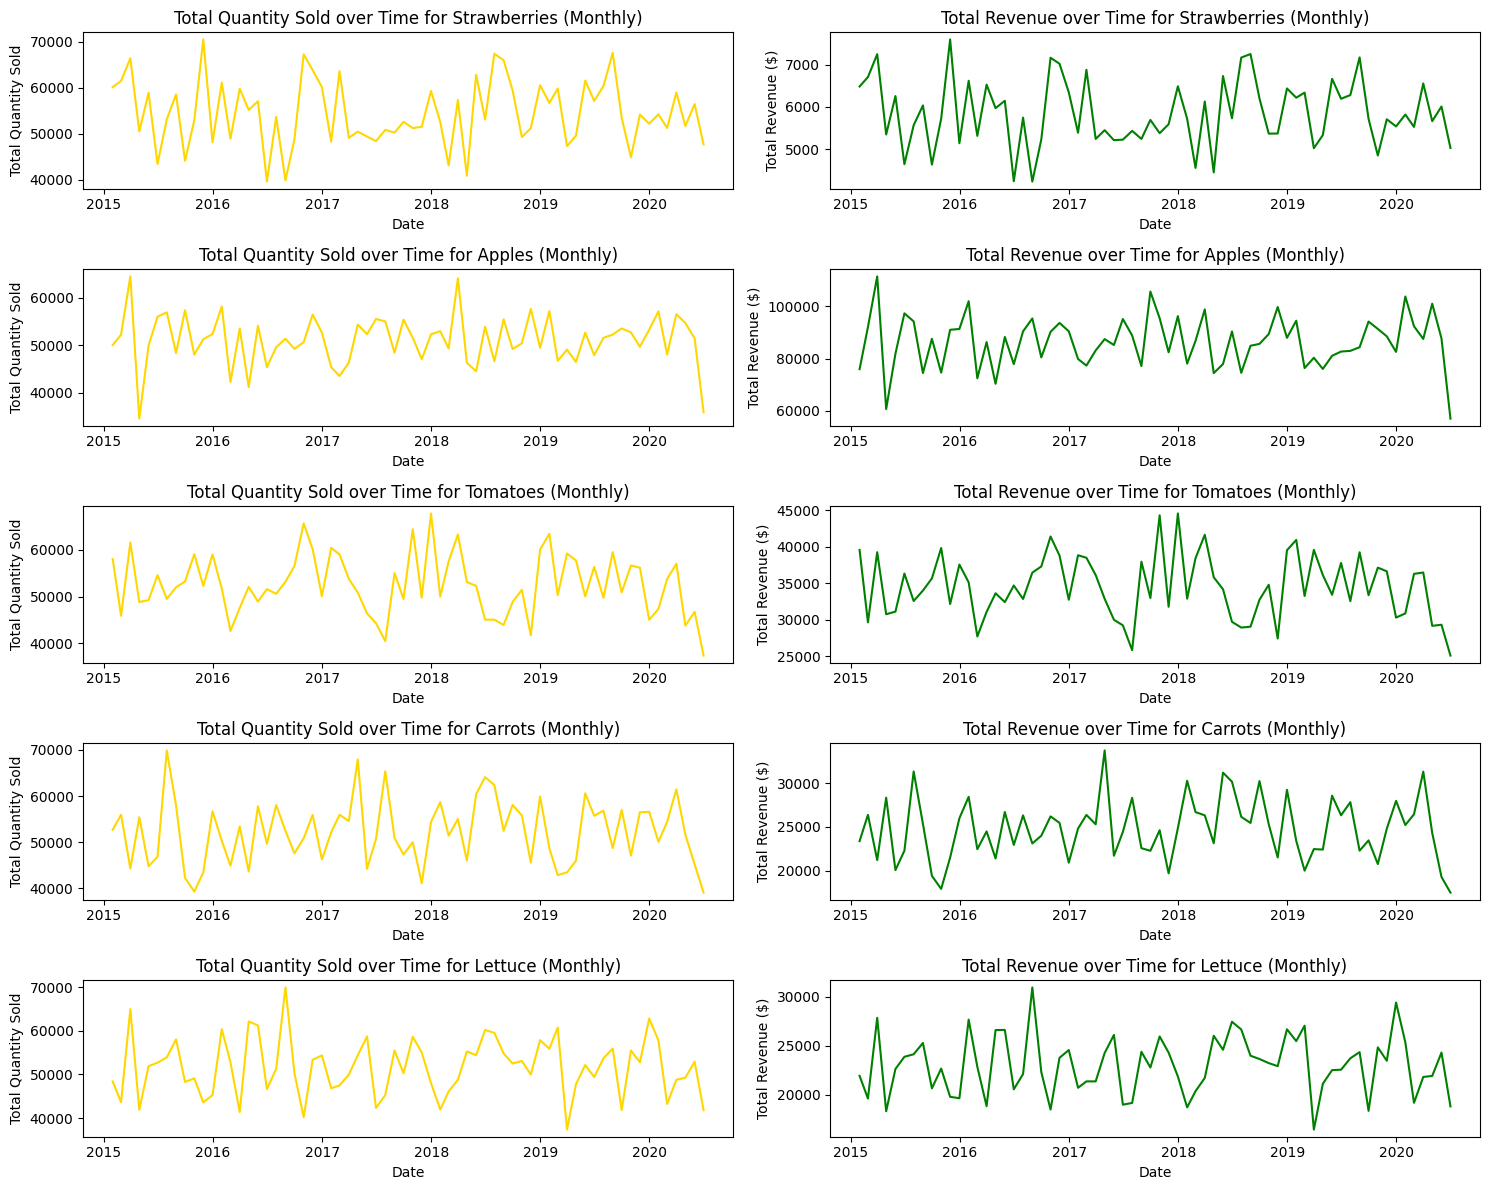

In [ ]:

products = df['Product'].unique()

fig, ax = plt.subplots(len(products), 2, figsize=(15, 12))

for i, product in enumerate(products):
    time_based_data = df[df['Product'] == product]
    time_based_data = time_based_data.groupby('Date').agg({
        'Quantity_Sold': 'sum',  # Somme des quantités vendues par date
        'Revenue': 'sum'  # Somme des revenus par date
    }).reset_index()  # Réinitialisation des index pour obtenir un DataFrame


    time_based_data = time_based_data.set_index('Date').resample('M').sum().reset_index()

    #
    sns.lineplot(x='Date', y='Quantity_Sold', data=time_based_data, ax=ax[i, 0], color='gold')
    ax[i, 0].set_title(f'Total Quantity Sold over Time for {product} (Monthly)')  # Titre du graphique
    ax[i, 0].set_xlabel('Date')  # Label de l'axe x
    ax[i, 0].set_ylabel('Total Quantity Sold')  # Label de l'axe

    #


    sns.lineplot(x='Date', y='Revenue', data=time_based_data, ax=ax[i, 1], color='green')
    ax[i, 1].set_title(f'Total Revenue over Time for {product} (Monthly)')  # Titre du graphique
    ax[i, 1].set_xlabel('Date')  # Label de l'axe x
    ax[i, 1].set_ylabel('Total Revenue ($)')  # Label de l'axe

plt.tight_layout()
plt.show()
plt.close('all')

####Feature Engineering

    we are going to be splitting the dataset into train and test sets

In [ ]:
# Création de deux dictionnaires pour stocker les données d'entraînement et de test
train_data = dict()
test_data = dict()

# Pour chaque produit dans la liste des produits
for product in products:
    # Filtrer les données pour le produit actuel
    df_product = df[df['Product'] == product]

    # Agréger les données par date, en calculant la somme des quantités vendues et des revenus
    df_product = df_product.groupby('Date').agg({
        'Quantity_Sold': 'sum',  # Somme des quantités vendues par date
        'Revenue': 'sum'  # Somme des revenus par date
    }).reset_index()  # Réinitialisation des index pour obtenir un DataFrame

    # Rééchantillonner les données par mois et calculer la somme des quantités vendues et des revenus
    df_product = df_product.set_index('Date').resample('M').sum().reset_index()

    # Séparer les données d'entraînement (avant 2019) et de test (à partir de 2019)
    train_data[product] = df_product[df_product['Date'].dt.year < 2019].reset_index(drop=True)
    test_data[product] = df_product[df_product['Date'].dt.year >= 2019].reset_index(drop=True)


Visualize the split

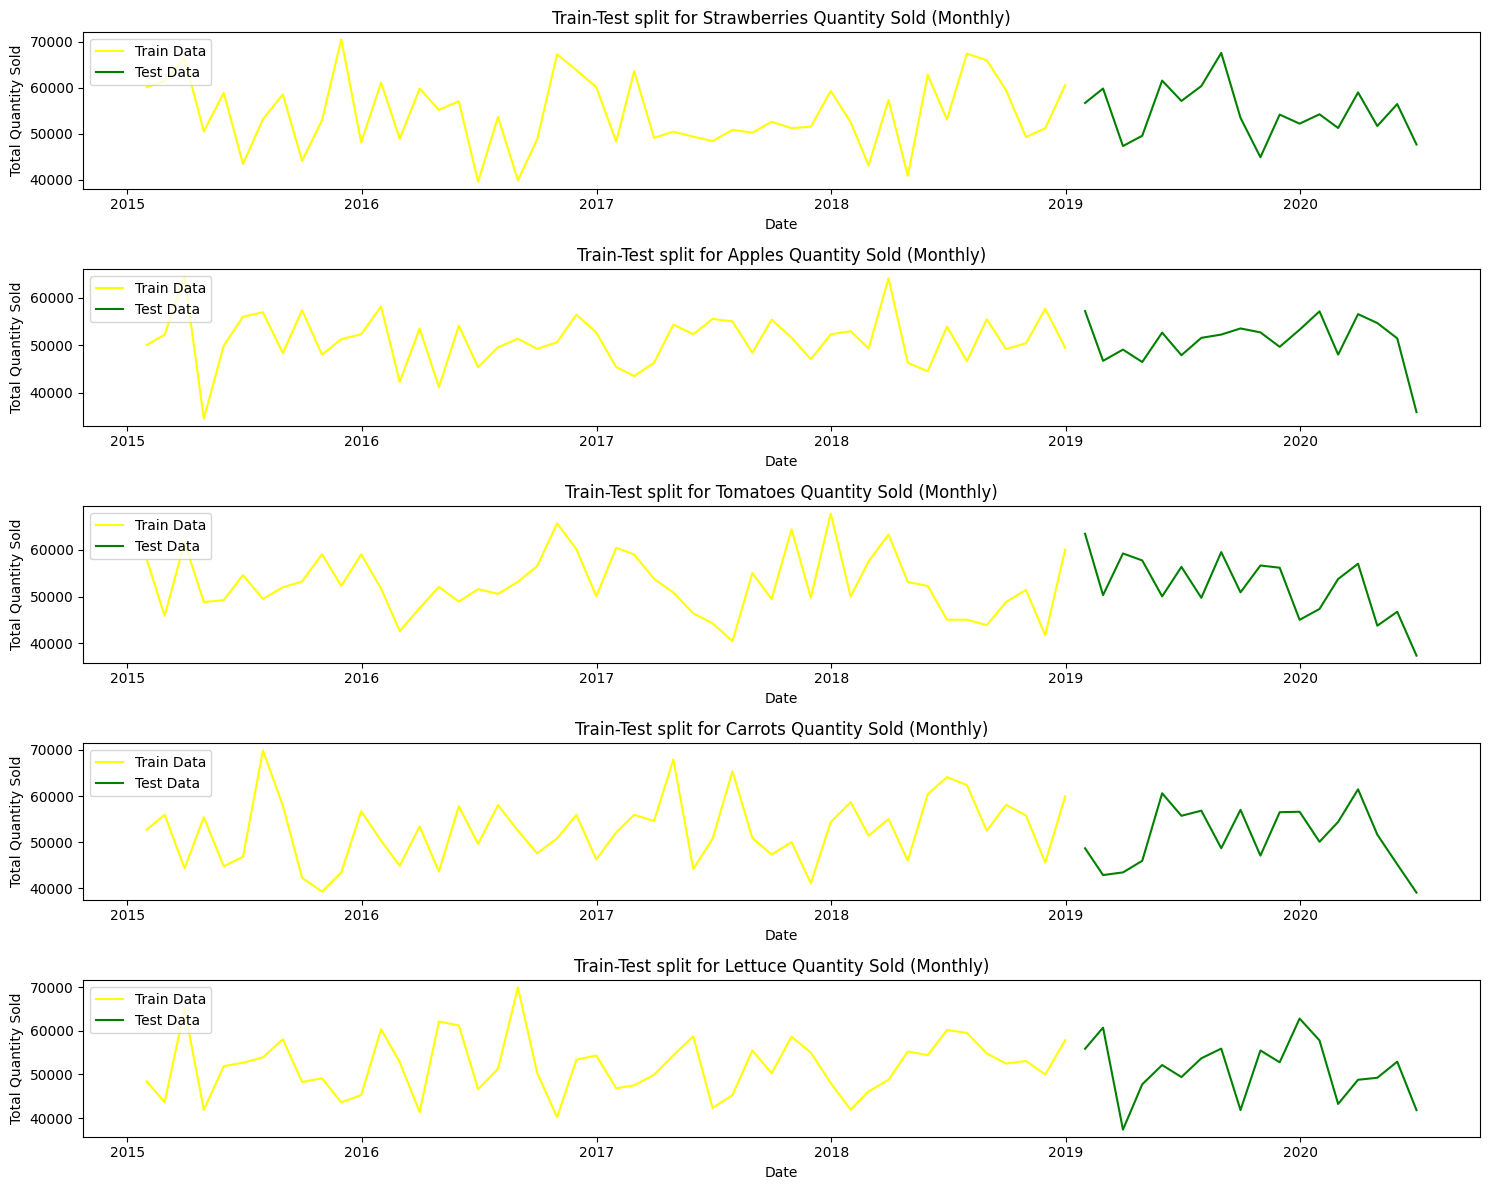

In [ ]:
# Création d'une figure avec un sous-graphe pour chaque produit
fig, ax = plt.subplots(len(products), 1, figsize=(15, 12))

# Pour chaque produit et son index dans la liste des produits
for i, product in enumerate(products):
    # Tracer les données d'entraînement en jaune
    ax[i].plot(train_data[product]['Date'], train_data[product]['Quantity_Sold'], color='yellow')
    # Tracer les données de test en vert
    ax[i].plot(test_data[product]['Date'], test_data[product]['Quantity_Sold'], color='green')

    # Titre du graphique pour le produit actuel
    ax[i].set_title(f'Train-Test split for {product} Quantity Sold (Monthly)')
    # Label de l'axe x
    ax[i].set_xlabel('Date')
    # Label de l'axe y
    ax[i].set_ylabel('Total Quantity Sold')
    # Légende du graphique
    ax[i].legend(['Train Data', 'Test Data'], loc='upper left')

# Ajuster l'espacement entre les sous-graphes pour une meilleure présentation
plt.tight_layout()

# Afficher la figure à l'écran
plt.show()

# Fermer toutes les figures ouvertes pour libérer la mémoire
plt.close('all')

###Modelling

We models that  will be used include:

-   ARIMA

-   Prophet

-   RandomForestRegressor



For evaluation, we will  be using :

-   Mean Absolute Error (MAE)

-   Root Mean Squared Error (RMSE)

-   Mean Absolute Percentage Error (MAPE)

###Forecasting with ARIMA

Write a function to perform stationarity test

In [ ]:
# Définition de la fonction adf_test pour effectuer le test de Dickey-Fuller augmenté sur une série temporelle
def adf_test(series):
    # Exécution du test ADF sur la série temporelle fournie
    result = adfuller(series)

    # Création d'une série pandas pour stocker les résultats du test
    dfoutput = pd.Series(result[0:4], index=['Test Statistic', 'p-value', '#lags used', 'number of observations used'])

    # Ajout des valeurs critiques au résultat sous forme de série pandas
    for key, value in result[4].items():
        dfoutput['Critical Value (%s)' % key] = value

    # Retour des résultats du test ADF
    return dfoutput

In [ ]:
# Dictionnaire pour stocker les résultats des tests de stationnarité pour chaque produit
stationarity_test = dict()

# Boucle sur chaque produit dans la liste des produits
for product in products:
    # Combinaison des données d'entraînement et de test pour le produit actuel
    product_data = pd.concat([train_data[product], test_data[product]])

    # Exécution du test ADF sur la série temporelle 'Quantity_Sold' pour le produit actuel
    stationarity_test[product] = adf_test(product_data['Quantity_Sold'])

# Conversion des résultats des tests de stationnarité en DataFrame pour une meilleure visualisation
pd.DataFrame(stationarity_test)

,Strawberries,Apples,Tomatoes,Carrots,Lettuce
Test Statistic,-5.058980,-9.876209e+00,-4.368359,-7.209263e+00,-7.433840e+00
p-value,0.000017,3.876435e-17,0.000338,2.257203e-10,6.258368e-11
#lags used,2.000000,0.000000e+00,8.000000,0.000000e+00,1.000000e+00
number of observations used,63.000000,6.500000e+01,57.000000,6.500000e+01,6.400000e+01
Critical Value (1%),-3.538695,-3.535217e+00,-3.550670,-3.535217e+00,-3.536928e+00
Critical Value (5%),-2.908645,-2.907154e+00,-2.913766,-2.907154e+00,-2.907887e+00
Critical Value (10%),-2.591897,-2.591103e+00,-2.594624,-2.591103e+00,-2.591493e+00


Plot ACF and PACF

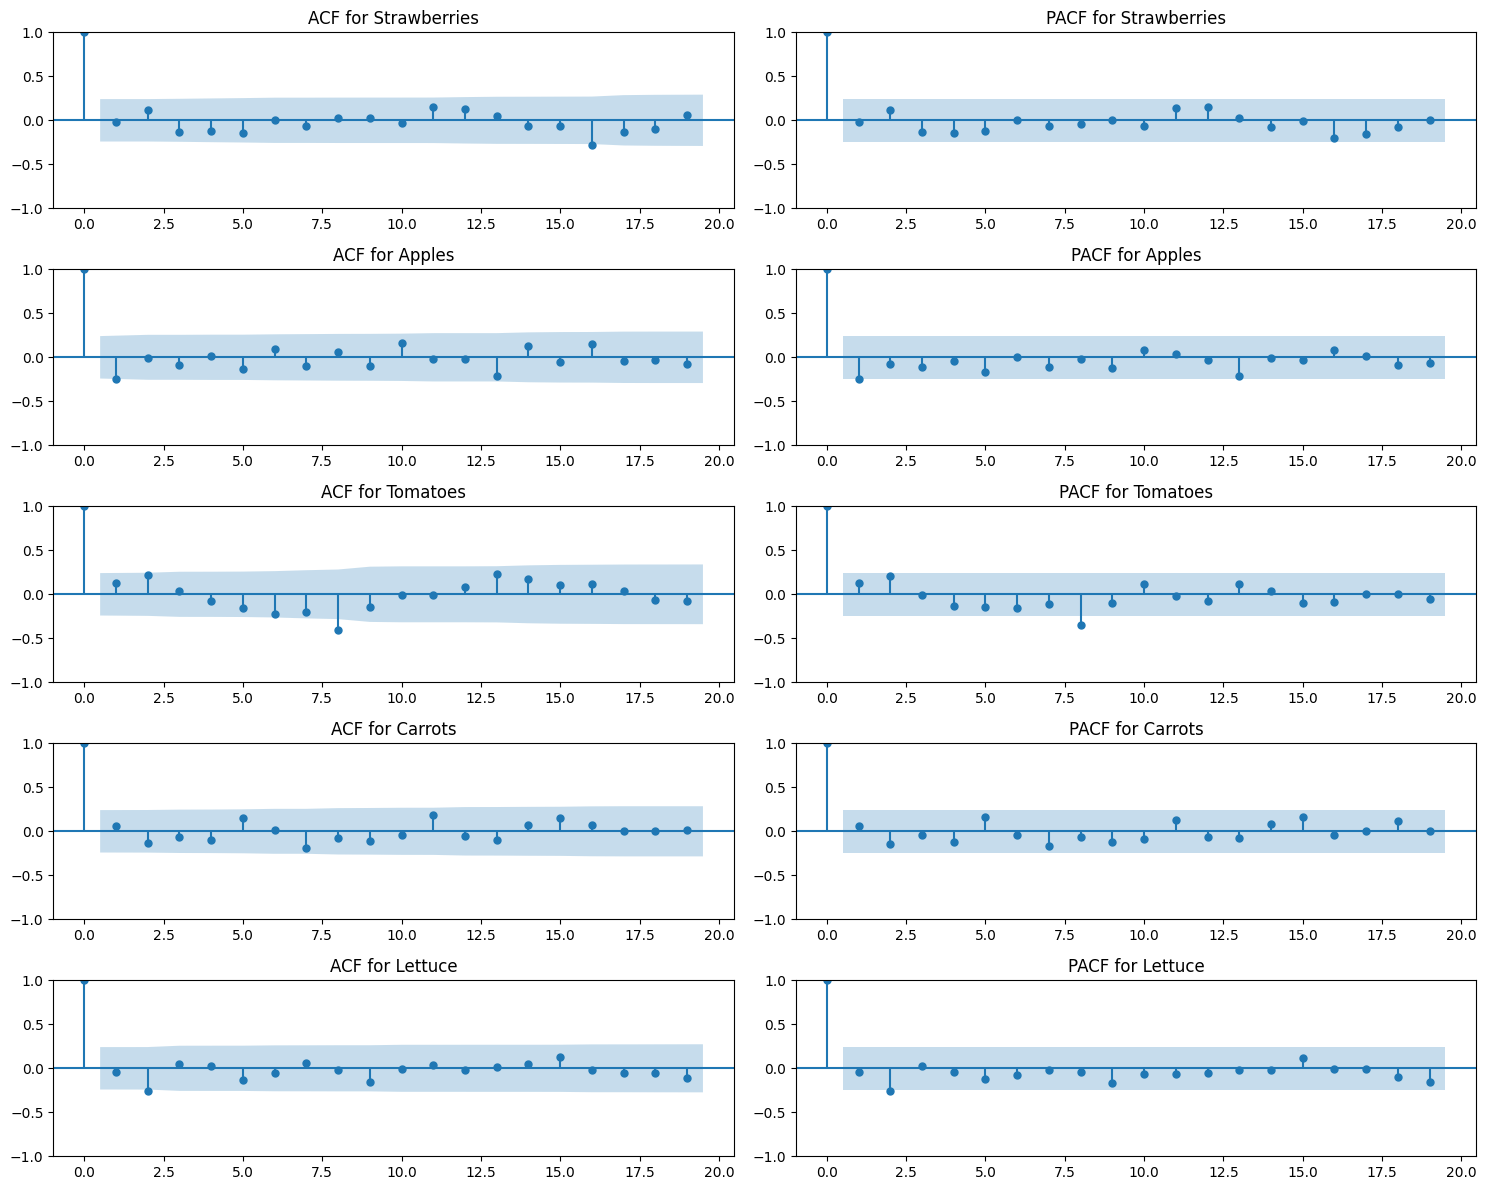

In [ ]:
fig, ax = plt.subplots(len(products), 2, figsize=(15, 12))

for i, product in enumerate(products):
    # Calculer
    product_data = pd.concat([train_data[product], test_data[product]])

    # Calculer l'ACF et l'PACF
    acf = plot_acf(product_data['Quantity_Sold'], ax=ax[i, 0], title  = f"ACF for {product}")

    pacf = plot_pacf(product_data['Quantity_Sold'], ax=ax[i, 1], title  = f"PACF for {product}")


plt.tight_layout()
plt.show()
plt.close('all')

Build  the models and evaluate  them

In [ ]:
!pip install --upgrade statsmodels

# Import the correct ARIMA class
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
# Initialisation des erreurs globales à zéro
mae, rmse, mape = 0, 0, 0

# Dictionnaire pour stocker les scores MAPE par produit
arima_mape_scores = dict()

# Dictionnaire pour stocker les prévisions ARIMA par produit
arima_forecasts = dict()

# Boucle sur chaque produit dans la liste des produits
for product in products:
    # Extraction des données d'entraînement et de test pour le produit actuel
    train = train_data[product]['Quantity_Sold'].values
    test = test_data[product]['Quantity_Sold'].values

    # Définition et ajustement du modèle ARIMA (1, 0, 1)
    model = ARIMA(train, order=(1, 0, 1))
    model_fit = model.fit()

    # Prévision pour la période de test
    forecast = model_fit.forecast(steps=len(test))

    # Stockage des prévisions dans le dictionnaire
    arima_forecasts[product] = forecast

    # Calcul des métriques d'évaluation pour le produit actuel
    product_mae = mean_absolute_error(test, forecast)
    product_rmse = mean_squared_error(test, forecast, squared=False)
    product_mape = mean_absolute_percentage_error(test, forecast) * 100

    # Ajout des métriques du produit aux erreurs globales
    mae += product_mae
    rmse += product_rmse
    mape += product_mape

    # Stockage du score MAPE du produit dans le dictionnaire
    arima_mape_scores[product] = product_mape

# Calcul des erreurs moyennes globales
n_products = len(products)
mae /= n_products
rmse /= n_products
mape /= n_products

# Affichage des erreurs moyennes globales
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}")

Mean Absolute Error (MAE): 4915.421081740114
Root Mean Squared Error (RMSE): 6059.514285748119
Mean Absolute Percentage Error (MAPE): 9.971576208042409


Plot the  train, test and forecast data

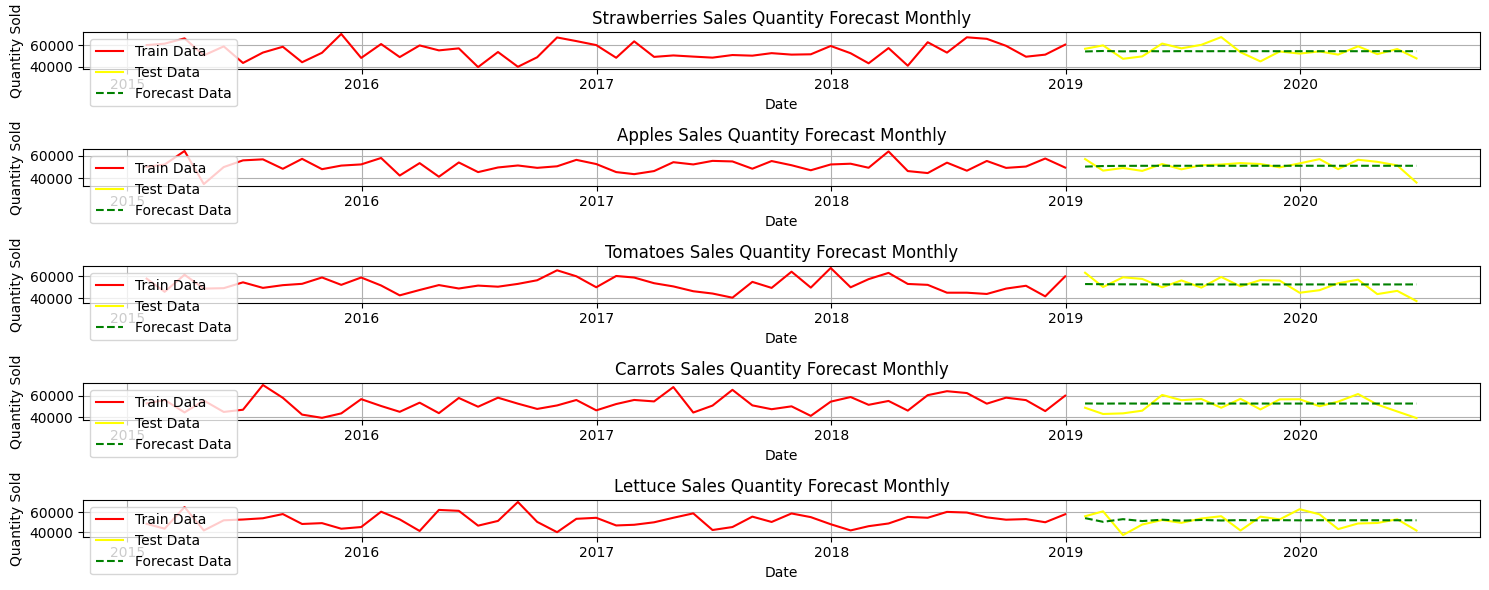

In [ ]:

# Définition de la taille de la figure
plt.figure(figsize=(15, 6))

# Boucle sur chaque produit et création d'un sous-graphique pour chaque produit
for i, product in enumerate(products):
    # Création d'un sous-graphique
    plt.subplot(len(products), 1, i+1)

    # Tracé des données d'entraînement (train_data) en rouge
    plt.plot(train_data[product]['Date'], train_data[product]['Quantity_Sold'], label='Actually Quantity Sold (Train Data)', color="red")

    # Tracé des données de test (test_data) en jaune
    plt.plot(test_data[product]['Date'], test_data[product]['Quantity_Sold'], label='Actually Quantity Sold (Test Data)', color="yellow")

    # Tracé des prévisions ARIMA en vert avec des tirets
    plt.plot(test_data[product]['Date'], arima_forecasts[product], label='Forecasted Quantity Sold', color="green", linestyle="--")

    # Définition du titre du sous-graphique
    plt.title(f"{product} Sales Quantity Forecast Monthly")

    # Étiquetage de l'axe des x
    plt.xlabel('Date')

    # Étiquetage de l'axe des y
    plt.ylabel('Quantity Sold')

    # Affichage de la légende
    plt.legend(['Train Data', 'Test Data', 'Forecast Data'])

    # Ajout d'une grille
    plt.grid(True)

# Ajustement de la mise en page pour éviter le chevauchement des éléments
plt.tight_layout()

# Affichage de la figure
plt.show()

# Fermeture de la figure
plt.close('all')


###Forecasting with  Prophet

With Prophet, we'll  train and evaluate the model

In [ ]:

# Initialisation des erreurs globales à zéro
mae, rmse, mape = 0, 0, 0

# Dictionnaires pour stocker les modèles Prophet, les prévisions et les scores MAPE
prophet_models = dict()
prophet_forecasts = dict()
prophet_mape_scores = dict()

# Boucle sur chaque produit dans la liste des produits
for product in products:
    # Extraction des données d'entraînement et de test pour le produit actuel
    train = train_data[product][['Date', 'Quantity_Sold']]
    test = test_data[product][['Date', 'Quantity_Sold']]

    # Renommage des colonnes pour être compatible avec Prophet
    train.columns = ['ds', 'y']
    test.columns = ['ds', 'y']

    # Définition et ajustement du modèle Prophet
    model_prophet = Prophet(yearly_seasonality=True, daily_seasonality=False)
    model_prophet.fit(train)

    # Stockage du modèle ajusté dans le dictionnaire
    prophet_models[product] = model_prophet

    # Création d'un DataFrame de dates futures pour les prévisions
    future_dates = model_prophet.make_future_dataframe(periods=len(test), freq='M')

    # Prévisions pour toutes les dates futures
    all_forecast = model_prophet.predict(future_dates)

    # Stockage des prévisions dans le dictionnaire
    prophet_forecasts[product] = all_forecast

    # Extraction des prévisions correspondant à la période de test
    test_forecast = all_forecast[-len(test):]

    # Calcul des métriques d'évaluation pour le produit actuel
    product_mae = mean_absolute_error(test['y'], test_forecast['yhat'])
    product_rmse = mean_squared_error(test['y'], test_forecast['yhat'], squared=False)
    product_mape = mean_absolute_percentage_error(test['y'], test_forecast['yhat']) * 100

    # Ajout des métriques du produit aux erreurs globales
    mae += product_mae
    rmse += product_rmse
    mape += product_mape

    # Stockage du score MAPE du produit dans le dictionnaire
    prophet_mape_scores[product] = product_mape

# Calcul des erreurs moyennes globales
n_products = len(products)
mae /= n_products
rmse /= n_products
mape /= n_products

# Affichage des erreurs moyennes globales
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}")


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpospkqxf9/1m76icfs.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpospkqxf9/ue_1jg17.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.10/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=13000', 'data', 'file=/tmp/tmpospkqxf9/1m76icfs.json', 'init=/tmp/tmpospkqxf9/ue_1jg17.json', 'output', 'file=/tmp/tmpospkqxf9/prophet_model4i19l_8b/prophet_model-20240722121655.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
12:16:55 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
12:16:55 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/

Mean Absolute Error (MAE): 6557.378103524502
Root Mean Squared Error (RMSE): 8136.561574969426
Mean Absolute Percentage Error (MAPE): 13.280853570273043


  Visualize the result

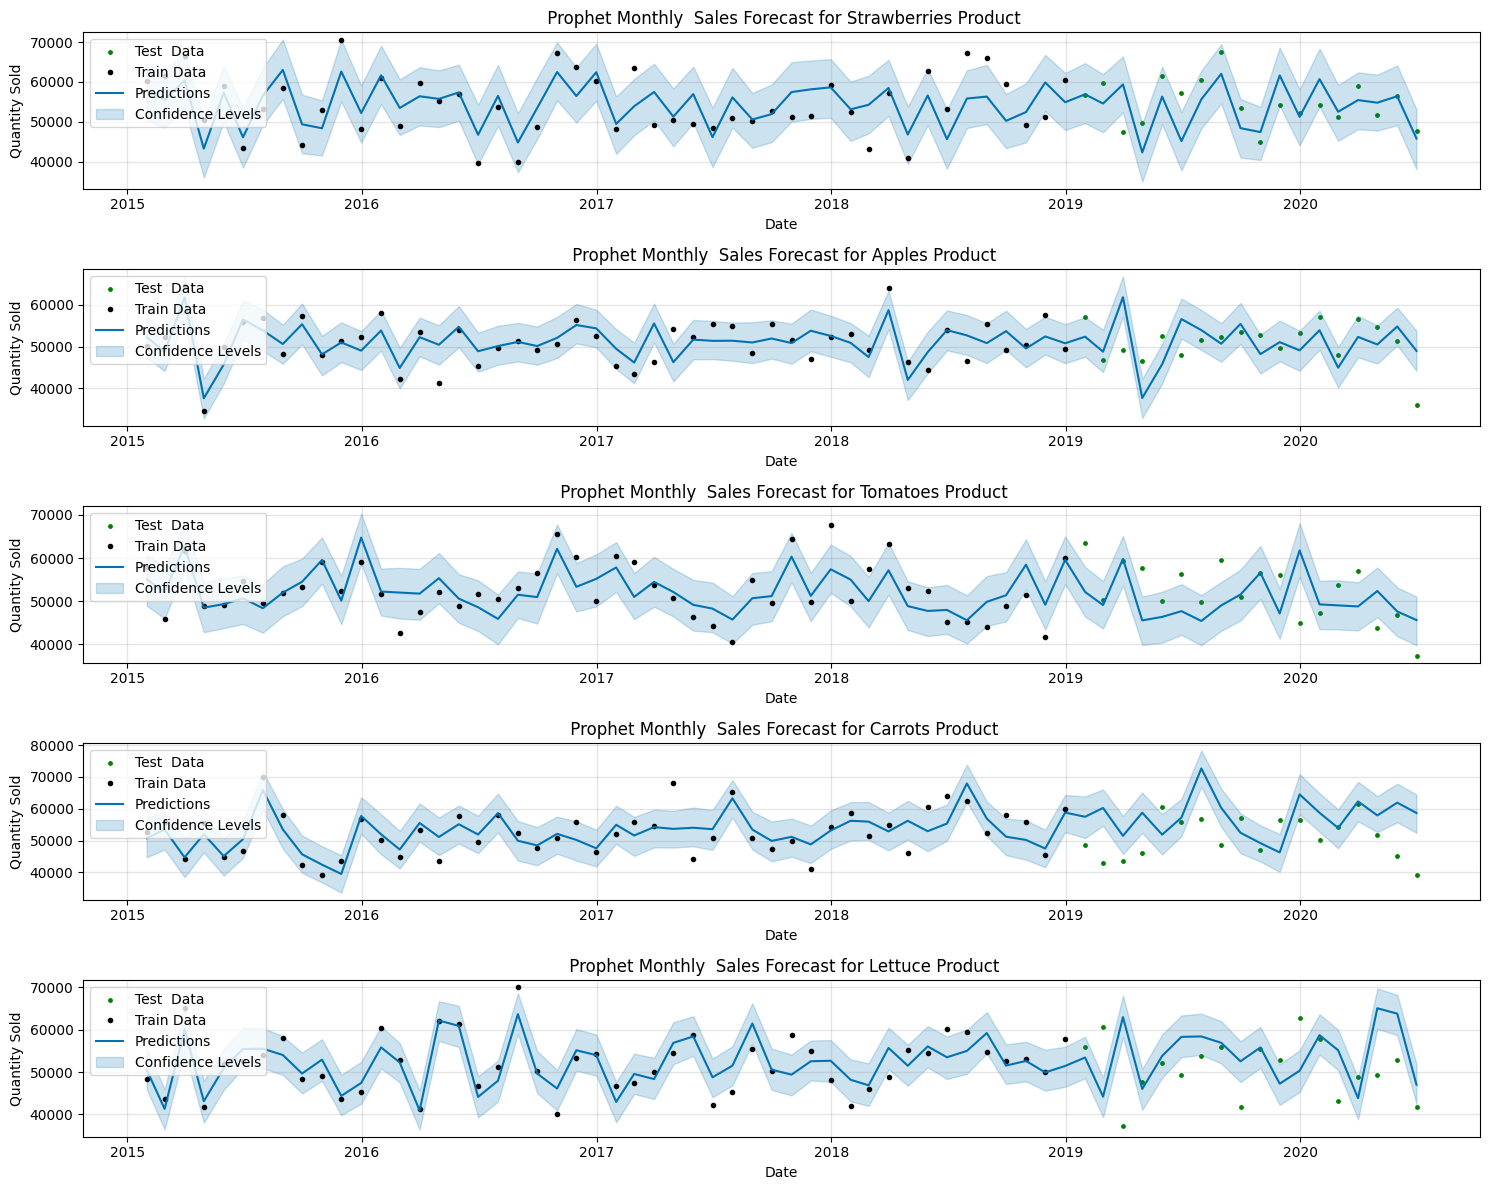

In [ ]:
fig, ax = plt.subplots(len(products), 1, figsize=(15, 12))

for i, product in enumerate(products):
    ax[i].scatter(test_data[product]['Date'], test_data[product]['Quantity_Sold'], color='green', s=6)

    category_plot = prophet_models[product].plot(prophet_forecasts[product], ax=ax[i], figsize=(15,7))
    ax[i].set_title(f' Prophet Monthly  Sales Forecast for {product} Product')
    ax[i].set_xlabel('Date')
    ax[i].set_ylabel('Quantity Sold')

    ax[i].legend(['Test  Data', 'Train Data', 'Predictions', 'Confidence Levels'], loc='upper left')

plt.tight_layout()
plt.show()
plt.close('all')

** Forecasting with RandomForestRegressor**



Train and evaluate the model

In [ ]:
mae, rmse, mape = 0, 0, 0

rf_mape_scores = dict()

rf_X_train_dates = dict()
rf_y_train = dict()
rf_forecasts = dict()
rf_X_test_dates = dict()
rf_y_test = dict()

for product in products:
    df_product = df[df['Product'] == product]

    df_product = pd.get_dummies(df_product, drop_first=True)

    df_product = df_product.set_index('Date').resample('M').sum().reset_index()

    df_product['Year'] = df_product['Date'].dt.year
    df_product['Month'] = df_product['Date'].dt.month
    df_product['Day'] = df_product['Date'].dt.day
    df_product['WeekOfYear'] = df_product['Date'].dt.isocalendar().week

    train = df_product[df_product['Year'] < 2019].reset_index()
    test = df_product[df_product['Year'] >= 2019].reset_index()

    rf_X_train_dates[product] = train['Date']
    rf_X_test_dates[product] = test['Date']

    train = train.drop(columns=['Date'])
    test = test.drop(columns=['Date'])

    X_train = train.drop(columns= ['Quantity_Sold', 'Revenue'])
    y_train = train['Quantity_Sold']

    X_test = test.drop(columns= ['Quantity_Sold', 'Revenue'])
    y_test = test['Quantity_Sold']

    rf_y_train[product] = y_train
    rf_y_test[product] = y_test

    rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)

    #forcecast == predictions == ypred
    forecast = rf_model.predict(X_test)
    rf_forecasts[product] = forecast

    product_mae = mean_absolute_error(y_test, forecast)
    product_rmse = mean_squared_error(y_test, forecast, squared=False)
    product_mape = mean_absolute_percentage_error(y_test, forecast) * 100

    mae += product_mae
    rmse += product_rmse
    mape += product_mape

    rf_mape_scores[product] = product_mape

mae /= n_products
rmse /= n_products
mape /= n_products

print()
print()

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}")



Mean Absolute Error (MAE): 2661.934684588824
Root Mean Squared Error (RMSE): 3177.6926944638376
Mean Absolute Percentage Error (MAPE): 5.203538526320775


Plottig the result



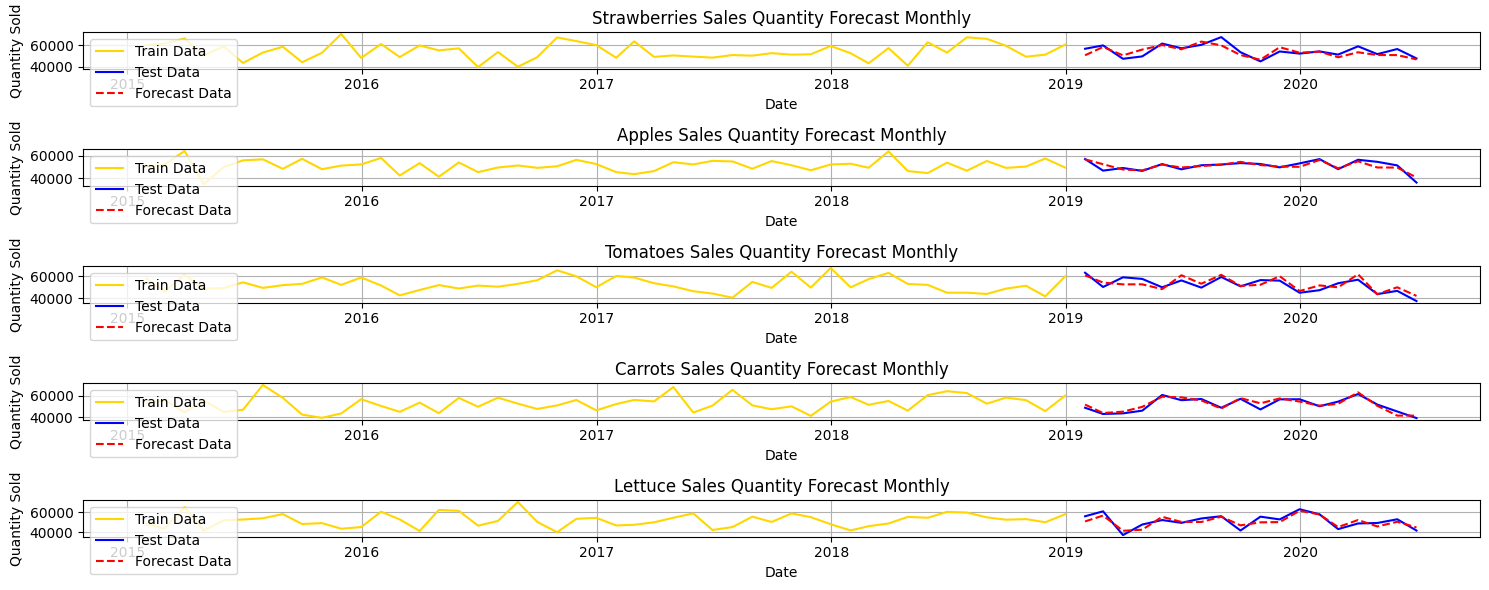

In [ ]:
plt.figure(figsize=(15, 6))

for i, product in enumerate(products):
    plt.subplot(len(products), 1, i+1)

    plt.plot(rf_X_train_dates[product], rf_y_train[product], label='Actually Quantity Sold (Train Data)', color="gold")

    plt.plot(rf_X_test_dates[product], rf_y_test[product], label='Actually Quantity Sold (Test Data)', color="blue")

    plt.plot(rf_X_test_dates[product], rf_forecasts[product], label='Forecasted Quantity Sold', color="red", linestyle="--")

    plt.title(f"{product} Sales Quantity Forecast Monthly")

    plt.xlabel('Date')

    plt.ylabel('Quantity Sold')

    plt.legend(['Train Data', 'Test Data', 'Forecast Data'])

    plt.grid(True)

plt.tight_layout()
plt.show()
plt.close('all')

###Conclusion

In [ ]:
arima_mape_scores['---Average---'] = np.mean([v for k, v in arima_mape_scores.items()])

prophet_mape_scores['---Average---'] = np.mean([v for k, v in prophet_mape_scores.items()])

rf_mape_scores['---Average---'] = np.mean([v for k, v in rf_mape_scores.items()])

pd.DataFrame({'ARIMA': arima_mape_scores, 'Prophet': prophet_mape_scores, 'RandomForestRegressor': rf_mape_scores})

,ARIMA,Prophet,RandomForestRegressor
Strawberries,8.252509,8.665478,5.482484
Apples,7.672138,10.521305,3.627103
Tomatoes,11.009154,12.012712,6.526076
Carrots,11.643816,18.719716,4.069554
Lettuce,11.280264,16.485058,6.312475
---Average---,9.971576,13.280854,5.203539


##**The best model is RandomForestRegressor because it has the lowest mape_score : `5.203539`**

